In [1]:
# ─── 0. COMPATIBILITY PATCH (numpy version mismatch) ─────────────────────────
import sys
import numpy
import numpy.core
sys.modules['numpy._core'] = numpy.core
sys.modules['numpy._core.numeric'] = numpy.core.numeric



In [1]:
# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────
import os
import numpy as np
import tensorflow as tf
import pickle as pkl
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from deepmreye.util import data_generator, model_opts
from deepmreye import train


2026-03-27 18:38:04.116997: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 18:38:04.190700: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-27 18:38:04.190758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-27 18:38:04.194378: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-27 18:38:04.207587: I tensorflow/core/platform/cpu_feature_guar

#  Zosia's part 

In [12]:


# ─── 2. HELPER FUNCTIONS ──────────────────────────────────────────────────────

def get_divided_paths(file_list, eye="left"):
    """Convert original .npz paths to left/right divided paths."""
    if eye not in ["left", "right"]:
        raise ValueError('eye must be "left" or "right"')
    divided_paths = []
    for orig_path in file_list:
        parts = orig_path.split(os.sep)
        dataset_folder = parts[5]
        filename = os.path.basename(orig_path)
        base = filename.replace(".npz", "")
        divided_path = os.path.join(
            f"/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/{eye}",
            dataset_folder,
            f"{base}_{eye}.npz"
        )
        divided_paths.append(divided_path)
    return divided_paths


def extract_features(npz_path, extractor):
    """Extract bottleneck features for all TRs in a single npz file."""
    f = np.load(npz_path, allow_pickle=True)
    data_keys = sorted([k for k in f.keys() if k.startswith('data_')])
    features = []
    for dk in data_keys:
        tr = f[dk][np.newaxis, ..., np.newaxis]
        features.append(extractor(tr, training=False).numpy()[0])
    return np.array(features)  # (n_TRs, 4608)


def cca_crossval(feats_left, feats_right, n_pre=10, n_splits=10):
    """Shuffle-split cross-validated CCA between left and right eye features."""
    n_trs = len(feats_left)
    rs_dim1, rs_dim2 = [], []

    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n_trs)
        train_idx = idx[:n_trs // 2]
        test_idx  = idx[n_trs // 2:]

        scaler_l = StandardScaler().fit(feats_left[train_idx])
        scaler_r = StandardScaler().fit(feats_right[train_idx])
        pca_l = PCA(n_components=n_pre).fit(scaler_l.transform(feats_left[train_idx]))
        pca_r = PCA(n_components=n_pre).fit(scaler_r.transform(feats_right[train_idx]))

        L_tr = pca_l.transform(scaler_l.transform(feats_left[train_idx]))
        R_tr = pca_r.transform(scaler_r.transform(feats_right[train_idx]))
        L_te = pca_l.transform(scaler_l.transform(feats_left[test_idx]))
        R_te = pca_r.transform(scaler_r.transform(feats_right[test_idx]))

        cca = CCA(n_components=2).fit(L_tr, R_tr)
        L_cca, R_cca = cca.transform(L_te, R_te)

        r1, _ = pearsonr(L_cca[:, 0], R_cca[:, 0])
        r2, _ = pearsonr(L_cca[:, 1], R_cca[:, 1])
        rs_dim1.append(r1)
        rs_dim2.append(r2)

    return np.mean(rs_dim1), np.std(rs_dim1), np.mean(rs_dim2), np.std(rs_dim2)

# ─── 3. TRAIN/TEST SPLIT ──────────────────────────────────────────────────────

all_files = []
for root, dirs, files in os.walk('/mnt/compneuro/deepmreye_finetuning/processed_data/'):
    if 'dataset7_resting_state' in root:
        continue
    for name in files:
        all_files.append(os.path.join(root, name))

datasets = {}
for f in all_files:
    dataset_name = os.path.basename(os.path.dirname(f))
    datasets.setdefault(dataset_name, []).append(f)

train_list, test_list = [], []
for dataset_name, files in datasets.items():
    files = sorted(files)
    np.random.shuffle(files)
    split_idx = int(0.8 * len(files))
    train_list.extend(files[:split_idx])
    test_list.extend(files[split_idx:])

print(f"Total train: {len(train_list)}  |  Total test: {len(test_list)}")

with open("train_list.txt", "w") as f:
    f.writelines(f"{p}\n" for p in train_list)
with open("test_list.txt", "w") as f:
    f.writelines(f"{p}\n" for p in test_list)

test_list_left   = get_divided_paths(test_list,  eye="left")
train_list_left  = get_divided_paths(train_list, eye="left")
test_list_right  = get_divided_paths(test_list,  eye="right")
train_list_right = get_divided_paths(train_list, eye="right")

# ─── 4. LOAD MODELS ───────────────────────────────────────────────────────────

opts = model_opts.get_opts()

generators_left = data_generator.create_generators(test_list_left, test_list_left)
generators_left = (*generators_left, test_list_left, test_list_left)
(_, model_inference_left) = train.train_model(
    dataset="prediction_on_left_eye",
    generators=generators_left,
    opts=opts,
    return_untrained=True
)
model_inference_left.load_weights('/mnt/compneuro/plgkoba/modelinference_left_eye_within_15degree.h5')
print("Left model loaded — input:", model_inference_left.input_shape)

generators_right = data_generator.create_generators(test_list_right, test_list_right)
generators_right = (*generators_right, test_list_right, test_list_right)
(_, model_inference_right) = train.train_model(
    dataset="prediction_on_right_eye",
    generators=generators_right,
    opts=opts,
    return_untrained=True
)
model_inference_right.load_weights('/mnt/compneuro/plgkoba/modelinference_right_eye_within15degree.h5')  # ← fixed bug
print("Right model loaded — input:", model_inference_right.input_shape)

# ─── 5. BUILD FEATURE EXTRACTORS ─────────────────────────────────────────────

feature_extractor_left = tf.keras.Model(
    inputs=model_inference_left.input,
    outputs=model_inference_left.get_layer('flatten').output
)
feature_extractor_right = tf.keras.Model(
    inputs=model_inference_right.input,
    outputs=model_inference_right.get_layer('flatten').output
)
feature_extractor_left.trainable  = False
feature_extractor_right.trainable = False
print("Bottleneck shape:", feature_extractor_left.output_shape)  # → (None, 4608)

# ─── 6. LOAD CLINICAL DATA ────────────────────────────────────────────────────

with open('/mnt/compneuro/stroke_clinical_and_neural_data_with_lesion_disconnectome.pkl', 'rb') as f:
    stroke_csv = pkl.load(f)

print("Clinical data loaded:", stroke_csv.shape)
print(stroke_csv.columns.tolist())

Total train: 210  |  Total test: 54
Training set (/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/left/dataset1_guided_fixations) contains 54 subjects: 
['sub-NDARGH074MU6_left', 'sub-NDAREK395BM3_left', 'sub-NDARTC865YNZ_left',
 'sub-NDARCR582GKJ_left', 'sub-NDARCK647MU6_left', 'sub-NDARXD710RLN_left',
 'sub-NDARCA690EBC_left', 'sub-NDARDB146NWY_left', 'sub-NDARDL305BT8_left',
 'sub-NDARGC148JBJ_left', 'sub-NDARTT272WT5_left', 'sub-NDARVC195NLH_left',
 'sub-NDARXE193CZ1_left', 'sub-NDARFE299MWU_left', 'sub-NDARCF052AE0_left',
 'sub-NDARDR439HY2_left', 'sub-NDARFR820KFF_left', 'sub-NDARAE358VBE_left',
 'sub-NDARRM073JKA_left', 'sub-NDARNM708YTF_left', 'sub-NDARRZ927VC3_left',
 'sub-NDAREN417DJE_left', 'sub-NDARGX443CEU_left', 'sub-NDAREH852JE0_left',
 'sub-NDARGV948BFZ_left', 'sub-NDARGH842VFY_left', 'sub-NDARCU865PBV_left',
 'sub-NDARCM811CV1_left', 'sub-NDARKK000PNQ_left', 'sub-NDARBT607PZL_left',
 'sub-NDARLU939YX4_left', 'sub-NDARAH948UF0_left', 'sub-NDARFG713PLR_l

ModuleNotFoundError: No module named 'numpy._core.numeric'

In [2]:
model_inference_right.summary()

NameError: name 'model_inference_right' is not defined

In [13]:
import os
import numpy as np
import tensorflow as tf
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

# ─── PATHS ────────────────────────────────────────────────────────────────────
RS_DIR  = '/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/right/dataset7_resting_state/'
D1_DIR  = '/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/right/dataset2_pursuit//'

# ─── HELPER FUNCTIONS ─────────────────────────────────────────────────────────

def load_features_and_labels(npz_path, extractor):
    """
    Returns:
        features  : (n_TRs, 4608)  — bottleneck features per TR
        mean_gaze : (n_TRs, 2)     — mean X/Y gaze position per TR (visual degrees)
        stability : (n_TRs,)       — mean within-TR gaze std (fixation instability)
    """
    f = np.load(npz_path, allow_pickle=True)
    data_keys  = sorted([k for k in f.keys() if k.startswith('data_')])
    label_keys = sorted([k for k in f.keys() if k.startswith('label_')])

    features, mean_gaze, stability = [], [], []
    for dk, lk in zip(data_keys, label_keys):
        tr  = f[dk][np.newaxis, ..., np.newaxis]          # (1, 24, 29, 18, 1)
        features.append(extractor(tr, training=False).numpy()[0])
        lab = f[lk]                                        # (10, 2) visual degrees
        mean_gaze.append(lab.mean(axis=0))                 # (2,)
        stability.append(lab.std(axis=0).mean())           # scalar

    return (np.array(features),
            np.array(mean_gaze),
            np.array(stability))


def gaze_regression_cv(features, labels, n_pca=50, n_splits=20):
    """
    Shuffle-split cross-validated ridge regression: bottleneck → gaze target.
    labels : (n_TRs, 2) for X/Y position, or (n_TRs,) for scalar target.
    Returns dict: {target_name: (mean_r, std_r)}
    """
    n = len(features)
    if n_pca >= n // 2:
        n_pca = max(5, n // 2 - 1)   # guard against rank deficiency

    X = PCA(n_components=n_pca).fit_transform(
            StandardScaler().fit_transform(features))

    scalar  = labels.ndim == 1
    targets = [labels]                      if scalar else [labels[:, 0], labels[:, 1]]
    names   = ['stability']                 if scalar else ['X', 'Y']

    results = {}
    for name, y in zip(names, targets):
        rs = []
        for seed in range(n_splits):
            rng = np.random.RandomState(seed)
            idx = rng.permutation(n)
            tr, te = idx[:n // 2], idx[n // 2:]
            reg = RidgeCV(alphas=[1, 10, 100, 1000]).fit(X[tr], y[tr])
            r, _ = pearsonr(reg.predict(X[te]), y[te])
            rs.append(r)
        results[name] = (np.mean(rs), np.std(rs))

    return results


def variance_audit(mean_gaze, stability, subj_id):
    """Print gaze range and std to assess how much signal exists."""
    print(f"  [{subj_id}] n_TRs={len(mean_gaze)}")
    print(f"    X: {mean_gaze[:,0].min():.2f}° – {mean_gaze[:,0].max():.2f}°  "
          f"std={mean_gaze[:,0].std():.3f}°")
    print(f"    Y: {mean_gaze[:,1].min():.2f}° – {mean_gaze[:,1].max():.2f}°  "
          f"std={mean_gaze[:,1].std():.3f}°")
    print(f"    within-TR stability (mean std): {stability.mean():.3f}°  "
          f"range=[{stability.min():.3f}, {stability.max():.3f}]")


def run_dataset(directory, extractor, label="dataset", audit=False, max_subjects=None):
    """Run variance audit + regression for all right-eye subjects in a directory."""
    files = sorted([f for f in os.listdir(directory) if f.endswith('_right.npz')])
    if max_subjects:
        files = files[:max_subjects]

    all_results = {}
    for fname in files:
        subj = fname.replace('_right.npz', '')
        npz_path = os.path.join(directory, fname)

        feats, mean_gaze, stability = load_features_and_labels(npz_path, extractor)

        if audit:
            variance_audit(mean_gaze, stability, subj)

        res_gaze = gaze_regression_cv(feats, mean_gaze)
        res_stab = gaze_regression_cv(feats, stability)

        all_results[subj] = {**res_gaze, **res_stab}

        print(f"  {label} | {subj}: "
              f"r_X={res_gaze['X'][0]:+.3f}±{res_gaze['X'][1]:.3f}  "
              f"r_Y={res_gaze['Y'][0]:+.3f}±{res_gaze['Y'][1]:.3f}  "
              f"r_stab={res_stab['stability'][0]:+.3f}±{res_stab['stability'][1]:.3f}")

    return all_results


# ─── LOAD RIGHT-EYE MODEL (assumed already loaded) ───────────────────────────
# feature_extractor_right should already exist from your model-loading block.
# If re-running from scratch, rebuild it:
#
# feature_extractor_right = tf.keras.Model(
#     inputs=model_inference_right.input,
#     outputs=model_inference_right.get_layer('flatten').output
# )
# feature_extractor_right.trainable = False

# ─── 1. VARIANCE AUDIT + REGRESSION: RESTING STATE ───────────────────────────
print("=" * 60)
print("DATASET 7 — Resting State (right eye)")
print("=" * 60)
rs_results = run_dataset(RS_DIR, feature_extractor_right,
                         label="RS", audit=True)

# ─── 2. SANITY CHECK: DATASET1 GUIDED FIXATIONS (first 5 subjects) ───────────
print("\n" + "=" * 60)
print("DATASET 1 — Guided Fixations (right eye, first 5 subjects)")
print("=" * 60)
d1_results = run_dataset(D1_DIR, feature_extractor_right,
                         label="D1", audit=True, max_subjects=5)

# ─── 3. SUMMARY ──────────────────────────────────────────────────────────────
def summarise(results, label):
    rx = np.array([v['X'][0]    for v in results.values()])
    ry = np.array([v['Y'][0]    for v in results.values()])
    rs = np.array([v['stability'][0] for v in results.values()])
    print(f"\n{label} summary (n={len(results)})")
    print(f"  r_X        : mean={rx.mean():+.3f}  median={np.median(rx):+.3f}  "
          f"range=[{rx.min():+.3f}, {rx.max():+.3f}]")
    print(f"  r_Y        : mean={ry.mean():+.3f}  median={np.median(ry):+.3f}  "
          f"range=[{ry.min():+.3f}, {ry.max():+.3f}]")
    print(f"  r_stability: mean={rs.mean():+.3f}  median={np.median(rs):+.3f}  "
          f"range=[{rs.min():+.3f}, {rs.max():+.3f}]")

print("\n" + "=" * 60)
summarise(rs_results, "Resting State")
summarise(d1_results, "Guided Fixations (subset)")

DATASET 7 — Resting State (right eye)


2026-03-27 18:50:03.470321: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-03-27 18:50:03.563057: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-27 18:50:03.752254: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


  [9001] n_TRs=182
    X: -3.41° – 2.72°  std=0.845°
    Y: -3.44° – 2.38°  std=1.038°
    within-TR stability (mean std): 1.086°  range=[0.309, 2.426]
  RS | 9001: r_X=+0.560±0.048  r_Y=+0.072±0.068  r_stab=+0.059±0.068
  [9007] n_TRs=182
    X: -4.53° – 3.55°  std=1.872°
    Y: -4.90° – 3.71°  std=1.466°
    within-TR stability (mean std): 0.559°  range=[0.000, 2.073]
  RS | 9007: r_X=+0.667±0.056  r_Y=+0.678±0.046  r_stab=+0.015±0.114
  [9008] n_TRs=182
    X: -3.13° – 2.25°  std=0.921°
    Y: -4.52° – 3.20°  std=1.049°
    within-TR stability (mean std): 0.562°  range=[0.000, 1.760]
  RS | 9008: r_X=+0.444±0.059  r_Y=+0.577±0.056  r_stab=+0.272±0.083
  [9013] n_TRs=182
    X: -3.70° – 3.05°  std=1.432°
    Y: -4.79° – 1.42°  std=1.389°
    within-TR stability (mean std): 0.395°  range=[0.056, 2.013]
  RS | 9013: r_X=+0.817±0.028  r_Y=+0.863±0.017  r_stab=+0.007±0.083
  [9023] n_TRs=182
    X: -1.52° – 2.23°  std=0.656°
    Y: -0.81° – 3.67°  std=1.141°
    within-TR stability (mean

KeyboardInterrupt: 

In [14]:
import pandas as pd

# ─── 1. FIT A SUBJECT-LEVEL RIDGE DECODER (full data, no CV) ─────────────────
# Use all TRs to fit the best possible X/Y decoder per subject,
# then extract: decoded gaze, residuals, and PC scores as features.

def fit_decoder_and_extract(npz_path, extractor, n_pca=50):
    """
    Returns a DataFrame with one row per TR:
      - feat_pc1 … feat_pc50  : PCA-compressed bottleneck features
      - gaze_x_true, gaze_y_true : eye-tracker labels (mean per TR)
      - gaze_x_pred, gaze_y_pred : ridge-decoded gaze
      - gaze_x_resid, gaze_y_resid : residuals (true - pred)
      - stability : within-TR gaze std
      - subj, tr_idx
    """
    f = np.load(npz_path, allow_pickle=True)
    data_keys  = sorted([k for k in f.keys() if k.startswith('data_')])
    label_keys = sorted([k for k in f.keys() if k.startswith('label_')])
    id_keys    = sorted([k for k in f.keys() if k.startswith('identifier_')])

    features, mean_gaze, stability, tr_indices = [], [], [], []
    for dk, lk, ik in zip(data_keys, label_keys, id_keys):
        tr = f[dk][np.newaxis, ..., np.newaxis]
        features.append(extractor(tr, training=False).numpy()[0])
        lab = f[lk]
        mean_gaze.append(lab.mean(axis=0))
        stability.append(lab.std(axis=0).mean())
        tr_indices.append(int(f[ik][1]))     # TR index from identifier

    features   = np.array(features)
    mean_gaze  = np.array(mean_gaze)
    stability  = np.array(stability)
    subj_id    = str(f[id_keys[0]][0]).replace('_right', '')

    # PCA compression
    scaler = StandardScaler()
    pca    = PCA(n_components=n_pca)
    X_pca  = pca.fit_transform(scaler.fit_transform(features))

    # Fit ridge decoder on all TRs (for feature extraction, not evaluation)
    reg_x = RidgeCV(alphas=[1, 10, 100, 1000]).fit(X_pca, mean_gaze[:, 0])
    reg_y = RidgeCV(alphas=[1, 10, 100, 1000]).fit(X_pca, mean_gaze[:, 1])
    pred_x = reg_x.predict(X_pca)
    pred_y = reg_y.predict(X_pca)

    df = pd.DataFrame(
        X_pca, columns=[f'feat_pc{i+1}' for i in range(n_pca)]
    )
    df['gaze_x_true']  = mean_gaze[:, 0]
    df['gaze_y_true']  = mean_gaze[:, 1]
    df['gaze_x_pred']  = pred_x
    df['gaze_y_pred']  = pred_y
    df['gaze_x_resid'] = mean_gaze[:, 0] - pred_x
    df['gaze_y_resid'] = mean_gaze[:, 1] - pred_y
    df['stability']    = stability
    df['subj']         = subj_id
    df['tr_idx']       = tr_indices

    return df, pca.explained_variance_ratio_

# ─── 2. RUN FOR ALL RS SUBJECTS ──────────────────────────────────────────────
all_dfs = []
evr_dict = {}

for fname in sorted(os.listdir(RS_DIR)):
    if not fname.endswith('_right.npz'):
        continue
    subj = fname.replace('_right.npz', '')
    df, evr = fit_decoder_and_extract(
        os.path.join(RS_DIR, fname), feature_extractor_right)
    all_dfs.append(df)
    evr_dict[subj] = evr
    print(f"  {subj}: {len(df)} TRs extracted")

rs_full = pd.concat(all_dfs, ignore_index=True)
rs_full.to_csv('rs_features_and_gaze.csv', index=False)
print(f"\nSaved: {rs_full.shape}")
print(rs_full[['subj', 'gaze_x_true', 'gaze_y_true',
               'gaze_x_pred', 'stability']].groupby('subj').describe().round(3))

  9001: 182 TRs extracted
  9007: 182 TRs extracted
  9008: 182 TRs extracted
  9013: 182 TRs extracted
  9023: 182 TRs extracted
  9025: 182 TRs extracted
  9029: 182 TRs extracted
  9033: 182 TRs extracted
  9041: 182 TRs extracted
  9048: 182 TRs extracted
  9050: 182 TRs extracted
  9053: 182 TRs extracted
  9055: 182 TRs extracted
  9057: 182 TRs extracted
  9063: 182 TRs extracted
  9070: 182 TRs extracted
  9071: 182 TRs extracted
  9074: 182 TRs extracted
  9077: 182 TRs extracted
  9081: 182 TRs extracted
  9082: 182 TRs extracted
  9083: 182 TRs extracted
  9084: 182 TRs extracted
  9085: 182 TRs extracted
  9087: 182 TRs extracted
  9088: 182 TRs extracted
  9091: 182 TRs extracted
  9092: 182 TRs extracted
  9100: 182 TRs extracted

Saved: (5278, 59)
     gaze_x_true                                                  gaze_y_true  \
           count   mean    std    min    25%    50%    75%    max       count   
subj                                                             

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rs = pd.read_csv('rs_features_and_gaze.csv')
feat_cols = [c for c in rs.columns if c.startswith('feat_pc')]

# ─── A. Per-subject summary features → ready for clinical correlation ─────────
# Collapse timeseries to one row per subject with meaningful summary stats

def subject_summary(df):
    rows = []
    for subj, grp in df.groupby('subj'):
        row = {'subj': subj}
        # Gaze position stats
        row['gaze_x_mean']   = grp['gaze_x_true'].mean()
        row['gaze_y_mean']   = grp['gaze_y_true'].mean()
        row['gaze_x_std']    = grp['gaze_x_true'].std()
        row['gaze_y_std']    = grp['gaze_y_true'].std()
        row['gaze_x_range']  = grp['gaze_x_true'].max() - grp['gaze_x_true'].min()
        row['gaze_y_range']  = grp['gaze_y_true'].max() - grp['gaze_y_true'].min()
        # Fixation instability
        row['stability_mean'] = grp['stability'].mean()
        row['stability_std']  = grp['stability'].std()
        row['stability_max']  = grp['stability'].max()
        # Decoding quality proxy: r between true and pred gaze
        row['decode_r_x'], _ = pearsonr(grp['gaze_x_true'], grp['gaze_x_pred'])
        row['decode_r_y'], _ = pearsonr(grp['gaze_y_true'], grp['gaze_y_pred'])
        # Feature PC means (subject-level neural/oculomotor state)
        for col in feat_cols:
            row[f'{col}_mean'] = grp[col].mean()
        rows.append(row)
    return pd.DataFrame(rows)

subj_df = subject_summary(rs)
subj_df.to_csv('rs_subject_summary.csv', index=False)
print(subj_df[['subj','gaze_x_std','gaze_y_std',
               'stability_mean','decode_r_x','decode_r_y']].to_string(index=False))


# ─── B. Cross-subject PCA on mean feature vectors ─────────────────────────────
# Do subjects cluster in feature space? Any outliers?

feat_mean_cols = [f'{c}_mean' for c in feat_cols]
X_subj = StandardScaler().fit_transform(subj_df[feat_mean_cols].values)
pca_subj = PCA(n_components=5)
pcs = pca_subj.fit_transform(X_subj)

print("\nCross-subject PCA explained variance:", 
      np.round(pca_subj.explained_variance_ratio_, 3))

subj_df['subj_pc1'] = pcs[:, 0]
subj_df['subj_pc2'] = pcs[:, 1]
subj_df.to_csv('rs_subject_summary.csv', index=False)


# ─── C. Correlation: gaze features vs stability ───────────────────────────────
# Within each subject: do feature PCs track fixation stability over time?

print("\nWithin-subject r(feat_pc1, stability) per subject:")
for subj, grp in rs.groupby('subj'):
    r, p = spearmanr(grp['feat_pc1'], grp['stability'])
    print(f"  {subj}: rho={r:+.3f}  p={p:.3f}")

 subj  gaze_x_std  gaze_y_std  stability_mean  decode_r_x  decode_r_y
 9001    0.846994    1.040390        1.086492    0.762520    0.613194
 9007    1.877402    1.470378        0.558563    0.861441    0.850163
 9008    0.923445    1.051854        0.562062    0.723491    0.758276
 9013    1.435952    1.392433        0.395031    0.906261    0.932993
 9023    0.658281    1.143849        0.551367    0.637017    0.825561
 9025    1.198806    1.038141        0.635756    0.899509    0.831929
 9029    0.917426    1.086939        0.782039    0.710732    0.763219
 9033    0.827308    1.174718        0.784547    0.774158    0.804456
 9041    1.449691    1.219100        0.681729    0.911944    0.842070
 9048    1.849199    1.833548        0.447716    0.953584    0.944473
 9050    1.316505    1.233343        0.597924    0.563468    0.657191
 9053    0.957732    1.956204        0.833365    0.632684    0.945718
 9055    0.428616    0.697729        0.602775    0.540305    0.615414
 9057    1.155528   

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

resid_cols = ['gaze_x_resid', 'gaze_y_resid', 'stability']

# Per-subject: mean and std of residuals as summary
resid_summary = rs.groupby('subj')[resid_cols].agg(['mean','std']).reset_index()
resid_summary.columns = ['subj'] + [f'{c}_{s}' 
    for c in resid_cols for s in ['mean','std']]

subj_df = subj_df.merge(resid_summary, on='subj')
subj_df.to_csv('rs_subject_summary.csv', index=False)
print(subj_df[['subj','gaze_x_resid_std','gaze_y_resid_std']].to_string(index=False))

 subj  gaze_x_resid_std  gaze_y_resid_std
 9001          0.552763          0.828525
 9007          0.971319          0.780539
 9008          0.641561          0.690384
 9013          0.612098          0.506179
 9023          0.510963          0.658375
 9025          0.527079          0.578458
 9029          0.648215          0.710667
 9033          0.526835          0.704073
 9041          0.599112          0.661467
 9048          0.563927          0.607352
 9050          1.095631          0.936038
 9053          0.748562          0.641056
 9055          0.363326          0.558127
 9057          0.620242          0.988087
 9063          0.588776          0.888968
 9070          0.840240          0.898007
 9071          1.150205          1.102412
 9074          0.981132          0.653431
 9077          1.194962          1.018685
 9081          0.878250          0.700561
 9082          0.584079          0.458197
 9083          0.530288          0.741637
 9084          0.415491          0

In [19]:
# Check actual column names
stab_col  = 'stability_mean_x'
resid_x   = 'gaze_x_resid_std'
resid_y   = 'gaze_y_resid_std'

print(f"Columns confirmed: stability='{stab_col}'  resid_x='{resid_x}'  resid_y='{resid_y}'")

targets = {
    'gaze_x_std':   subj_df['gaze_x_std'].values,
    'gaze_y_std':   subj_df['gaze_y_std'].values,
    'stability':    subj_df[stab_col].values,
    'decode_r_x':   subj_df['decode_r_x'].values,
    'decode_r_y':   subj_df['decode_r_y'].values,
    'resid_x_std':  subj_df[resid_x].values,
    'resid_y_std':  subj_df[resid_y].values,
}

feat_mean_cols = [f'{c}_mean' for c in feat_cols]
X = StandardScaler().fit_transform(subj_df[feat_mean_cols].values)
X_pca = PCA(n_components=10).fit_transform(X)

print(f"\nSpearman r: subject-mean feature PCs vs. gaze metrics (n=29)")
print(f"{'Target':<22} {'rho_pc1':>9} {'rho_pc2':>9} {'rho_pc3':>9}")
for name, y in targets.items():
    rs_list = []
    for pc_idx in range(3):
        rho, p = spearmanr(X_pca[:, pc_idx], y)
        rs_list.append(f"{rho:+.3f}({'*' if p<0.05 else ' '})")
    print(f"  {name:<20} {rs_list[0]:>10} {rs_list[1]:>10} {rs_list[2]:>10}")

# RSA
feat_matrix = subj_df[feat_mean_cols].values
feat_dist = cdist(StandardScaler().fit_transform(feat_matrix),
                  StandardScaler().fit_transform(feat_matrix), metric='cosine')

gaze_vars = np.column_stack([
    subj_df['gaze_x_std'].values,
    subj_df['gaze_y_std'].values,
    subj_df[stab_col].values
])
gaze_dist = cdist(StandardScaler().fit_transform(gaze_vars),
                  StandardScaler().fit_transform(gaze_vars), metric='euclidean')

triu = np.triu_indices(len(subj_df), k=1)
rho, p = spearmanr(feat_dist[triu], gaze_dist[triu])
print(f"\nRSA (feature ↔ gaze distance matrices):")
print(f"  Spearman rho = {rho:.3f}  p = {p:.4f}  n_pairs = {len(triu[0])}")

# Autocorrelation
print(f"\nLag-1 autocorrelation: feat_pc1 vs. gaze_x_true")
print(f"{'subj':<10} {'AC_feat_pc1':>12} {'AC_gaze_x':>10}")
for subj, grp in rs.groupby('subj'):
    grp = grp.sort_values('tr_idx')
    ac_feat = np.corrcoef(grp['feat_pc1'].values[:-1], grp['feat_pc1'].values[1:])[0,1]
    ac_gaze = np.corrcoef(grp['gaze_x_true'].values[:-1], grp['gaze_x_true'].values[1:])[0,1]
    print(f"  {subj:<8}  {ac_feat:+.3f}        {ac_gaze:+.3f}")

Columns confirmed: stability='stability_mean_x'  resid_x='gaze_x_resid_std'  resid_y='gaze_y_resid_std'

Spearman r: subject-mean feature PCs vs. gaze metrics (n=29)
Target                   rho_pc1   rho_pc2   rho_pc3
  gaze_x_std            +0.115( )  +0.048( )  +0.433(*)
  gaze_y_std            -0.167( )  +0.162( )  +0.019( )
  stability             -0.066( )  -0.293( )  +0.001( )
  decode_r_x            +0.067( )  +0.176( )  +0.316( )
  decode_r_y            -0.195( )  +0.203( )  -0.046( )
  resid_x_std           +0.122( )  -0.076( )  +0.237( )
  resid_y_std           +0.068( )  +0.046( )  +0.053( )

RSA (feature ↔ gaze distance matrices):
  Spearman rho = 0.033  p = 0.5102  n_pairs = 406

Lag-1 autocorrelation: feat_pc1 vs. gaze_x_true
subj        AC_feat_pc1  AC_gaze_x
  9001      +0.173        +0.478
  9007      +0.413        +0.668
  9008      +0.526        +0.340
  9013      +0.590        +0.618
  9023      +0.662        +0.433
  9025      +0.248        +0.712
  9029      +0.6

In [18]:
from scipy.spatial.distance import cdist

In [50]:
# Cross-subject generalisation test:
# Train decoder on N-1 SleepyBrain subjects, test on left-out subject

from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import numpy as np

subj_ids = rs['subj'].unique()
results = {}

for test_subj in subj_ids:
    train = rs[rs['subj'] != test_subj]
    test  = rs[rs['subj'] == test_subj]

    feat_cols = [c for c in rs.columns if c.startswith('feat_pc')]

    scaler = StandardScaler().fit(train[feat_cols])
    pca    = PCA(n_components=50).fit(scaler.transform(train[feat_cols]))

    X_tr = pca.transform(scaler.transform(train[feat_cols]))
    X_te = pca.transform(scaler.transform(test[feat_cols]))

    r_x_list, r_y_list = [], []
    for col, bucket in [('gaze_x_true', r_x_list), ('gaze_y_true', r_y_list)]:
        reg = RidgeCV(alphas=[1,10,100,1000]).fit(X_tr, train[col])
        pred = reg.predict(X_te)
        r, _ = pearsonr(pred, test[col].values)
        bucket.append(r)

    results[test_subj] = (r_x_list[0], r_y_list[0])
    print(f"  {test_subj}: r_X={r_x_list[0]:+.3f}  r_Y={r_y_list[0]:+.3f}")

rx = np.array([v[0] for v in results.values()])
ry = np.array([v[1] for v in results.values()])
print(f"\nLeave-one-subject-out: r_X={rx.mean():.3f}±{rx.std():.3f}  "
      f"r_Y={ry.mean():.3f}±{ry.std():.3f}")

  9001: r_X=-0.159  r_Y=-0.032
  9007: r_X=-0.149  r_Y=+0.103
  9008: r_X=-0.165  r_Y=-0.079
  9013: r_X=-0.242  r_Y=+0.127
  9023: r_X=+0.050  r_Y=-0.084
  9025: r_X=-0.205  r_Y=-0.239
  9029: r_X=-0.087  r_Y=-0.010
  9033: r_X=+0.024  r_Y=+0.103
  9041: r_X=+0.026  r_Y=+0.330
  9048: r_X=-0.320  r_Y=+0.084
  9050: r_X=+0.070  r_Y=+0.123
  9053: r_X=-0.026  r_Y=-0.489
  9055: r_X=-0.215  r_Y=+0.089
  9057: r_X=-0.021  r_Y=-0.305
  9063: r_X=+0.047  r_Y=-0.187
  9070: r_X=+0.069  r_Y=-0.223
  9071: r_X=-0.065  r_Y=-0.051
  9074: r_X=+0.134  r_Y=+0.161
  9077: r_X=-0.030  r_Y=+0.105
  9081: r_X=+0.037  r_Y=+0.303
  9082: r_X=-0.056  r_Y=+0.272
  9083: r_X=-0.182  r_Y=-0.333
  9084: r_X=-0.358  r_Y=-0.096
  9085: r_X=+0.108  r_Y=-0.328
  9087: r_X=+0.187  r_Y=-0.147
  9088: r_X=-0.289  r_Y=+0.122
  9091: r_X=+0.083  r_Y=+0.077
  9092: r_X=-0.435  r_Y=-0.182
  9100: r_X=-0.350  r_Y=-0.072

Leave-one-subject-out: r_X=-0.087±0.163  r_Y=-0.030±0.200


# Using the +-1.5 degree TRs

In [52]:
import os
import numpy as np

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
THRESHOLD   = 1.5
input_base  = '/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/'
output_base = '/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/'

all_files_separate = []
for root, dirs, files in os.walk(input_base):
    if 'dataset7_resting_state' in root:
        continue
    for name in files:
        if name.endswith('.npz'):
            all_files_separate.append(os.path.join(root, name))

print(f"Total files found: {len(all_files_separate)}")

# ─── FILTER AND SAVE ──────────────────────────────────────────────────────────
saved_counts = {'right': 0, 'left': 0, 'unknown': 0}

for file_path in all_files_separate:
    data_npz = np.load(file_path, allow_pickle=True)
    keys     = list(data_npz.keys())

    fname = os.path.basename(file_path)
    if '_right' in fname:
        eye = 'right'
    elif '_left' in fname:
        eye = 'left'
    else:
        print(f"  WARNING: cannot determine eye side for {fname}, skipping")
        saved_counts['unknown'] += 1
        continue

    # Filter TRs within ±1.5°
    filtered_data, filtered_labels = {}, {}
    new_idx = 0

    for key in keys:
        if not key.startswith('data_'):
            continue
        idx       = key.split('_')[1]
        label_key = f'label_{idx}'
        if label_key not in data_npz:
            continue

        data  = data_npz[key]
        label = data_npz[label_key]

        med = np.median(label, axis=0)
        if (-THRESHOLD <= med[0] <= THRESHOLD and
            -THRESHOLD <= med[1] <= THRESHOLD):
            filtered_data[f'data_{new_idx}']    = data
            filtered_labels[f'label_{new_idx}'] = label
            new_idx += 1

    if not filtered_data:
        print(f"  SKIP (no TRs passed filter): {file_path}")
        continue

    # Mirror input directory structure under eye/
    rel_path  = os.path.relpath(file_path, os.path.join(input_base, eye))
    subfolder = os.path.dirname(rel_path)
    save_dir  = os.path.join(output_base, eye, subfolder)
    os.makedirs(save_dir, exist_ok=True)

    base_name = fname.replace('.npz', '_fix1p5.npz')
    save_path = os.path.join(save_dir, base_name)

    np.savez(save_path, **filtered_data, **filtered_labels)
    saved_counts[eye] += 1

    all_meds = np.array([np.median(filtered_labels[k], axis=0)
                         for k in filtered_labels])
    print(f"  {save_path}")
    print(f"    TRs kept: {new_idx}  |  "
          f"X: [{all_meds[:,0].min():.2f}, {all_meds[:,0].max():.2f}]°  "
          f"Y: [{all_meds[:,1].min():.2f}, {all_meds[:,1].max():.2f}]°")

print(f"\nDone. Saved — right: {saved_counts['right']}  left: {saved_counts['left']}")

Total files found: 792
  /mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAA948VFH_right_fix1p5.npz
    TRs kept: 30  |  X: [0.00, 0.00]°  Y: [0.00, 0.00]°
  /mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC349YUC_right_fix1p5.npz
    TRs kept: 30  |  X: [0.00, 0.00]°  Y: [0.00, 0.00]°
  /mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC350BZ0_right_fix1p5.npz
    TRs kept: 30  |  X: [0.00, 0.00]°  Y: [0.00, 0.00]°
  /mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC495TJ2_right_fix1p5.npz
    TRs kept: 30  |  X: [0.00, 0.00]°  Y: [0.00, 0.00]°
  /mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAD615WLJ_right_fix1p5.npz
    TRs kept: 30  |  X: [0.00, 0.00]°  Y: [0.00,

In [53]:
import os

# Search for the fix1p5 files wherever they were saved
found = []
for root, dirs, files in os.walk('/mnt/compneuro/deepmreye_finetuning/'):
    for f in files:
        if 'fix1p5' in f and f.endswith('.npz'):
            found.append(os.path.join(root, f))

print(f"Found: {len(found)} fix1p5 files")
for p in found[:10]:
    print(p)

Found: 792 fix1p5 files
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAA948VFH_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC349YUC_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC350BZ0_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAC495TJ2_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAD615WLJ_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAE012DGA_right_fix1p5.npz
/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/dataset1_guided_fixations/sub-NDARAE358VBE_right_fix1p5.npz
/mn

In [3]:
os.listdir('/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/')

['dataset1_guided_fixations',
 'dataset2_pursuit',
 'dataset3_pursuit',
 'dataset4_pursuit',
 'dataset5_free_viewing']

Left: 264  Right: 528


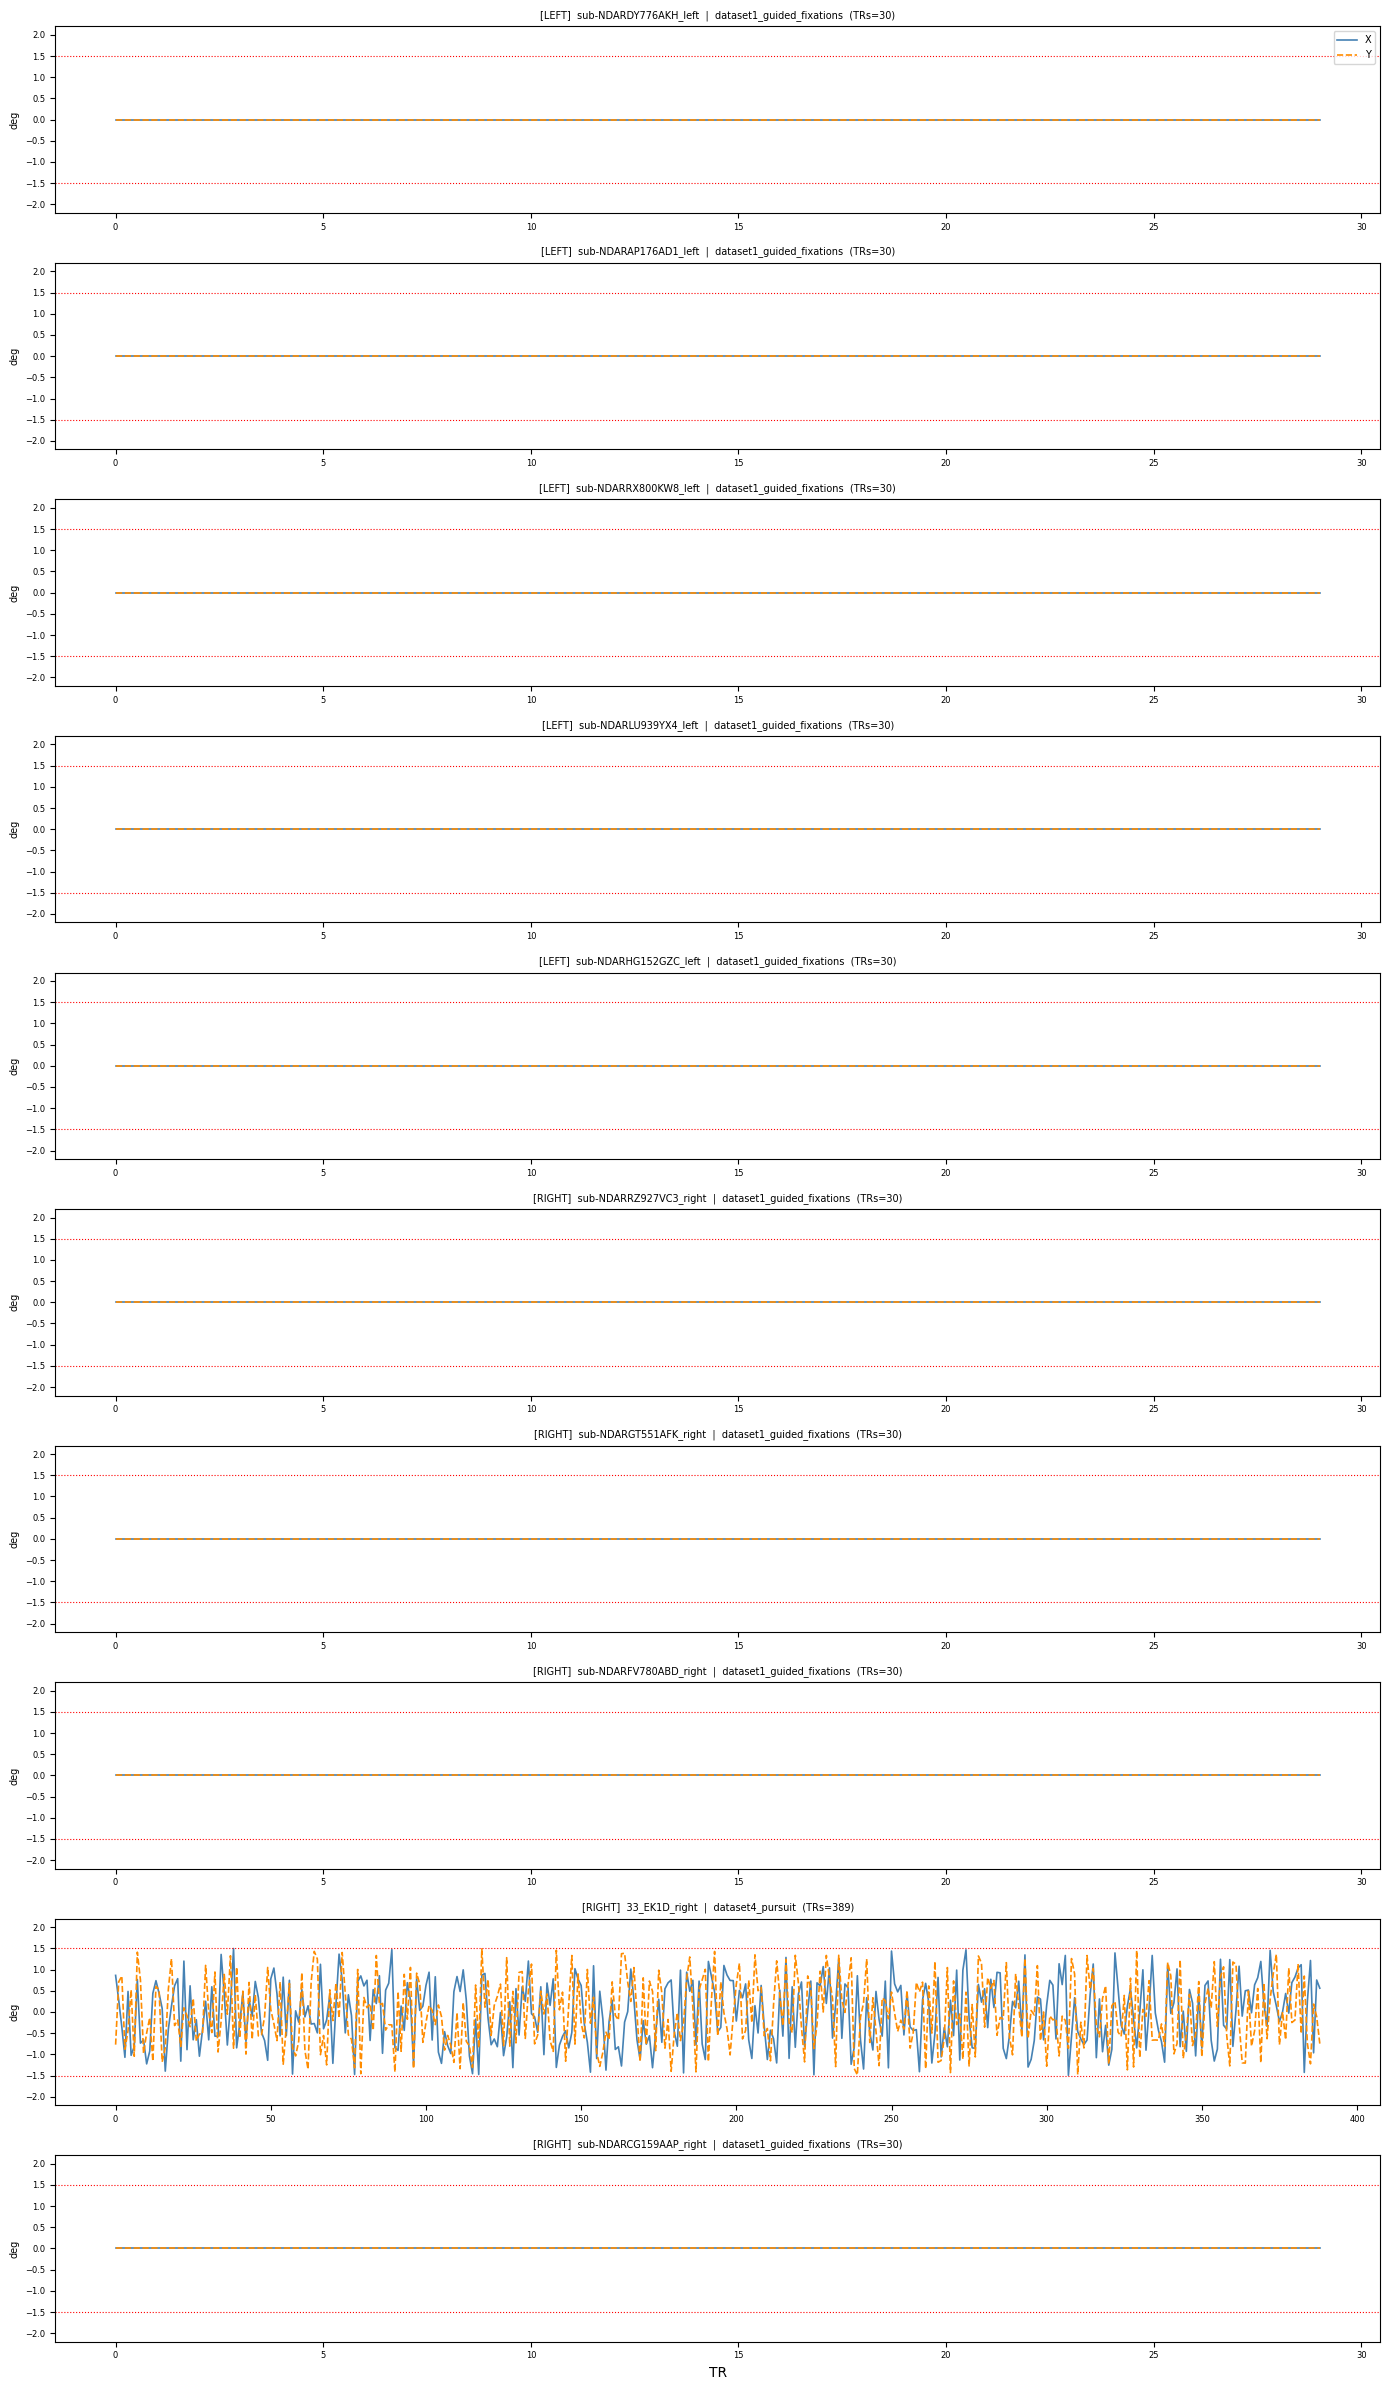

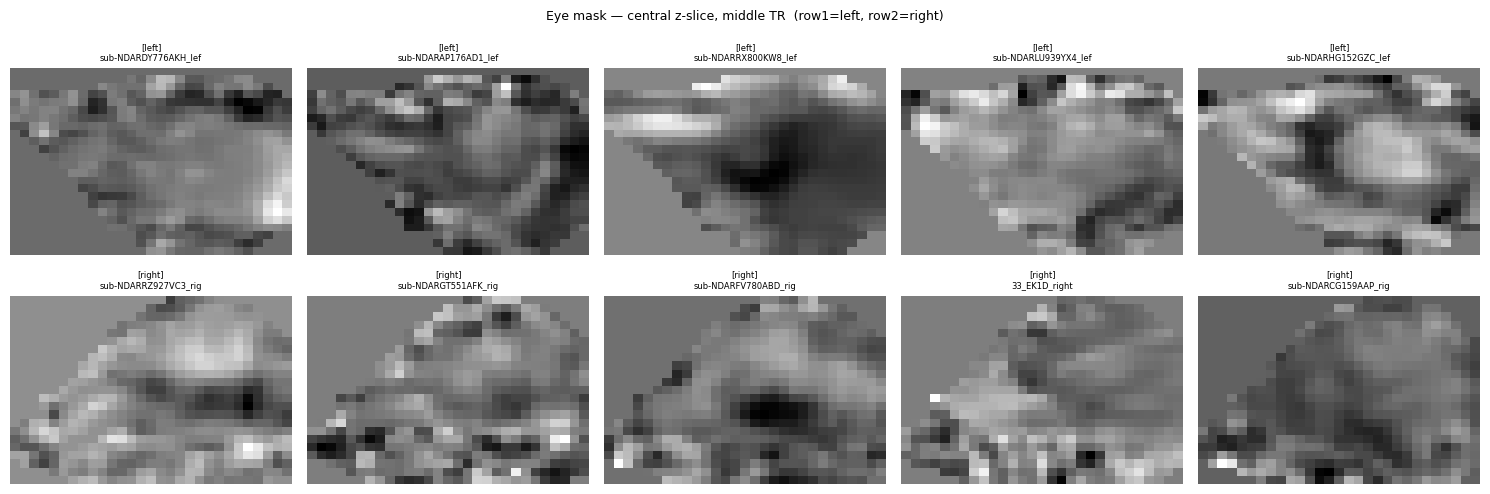

In [65]:
%matplotlib inline
import os, numpy as np, random, matplotlib.pyplot as plt
from collections import Counter

BASE = '/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/'

left_npz, right_npz = [], []
for root, dirs, files in os.walk(BASE):
    for f in files:
        if not f.endswith('.npz'):
            continue
        path = os.path.join(root, f)
        if '/left/' in path:
            left_npz.append(path)
        elif '/right/' in path:
            right_npz.append(path)

print(f"Left: {len(left_npz)}  Right: {len(right_npz)}")

random.seed(42)
sample_left  = random.sample(left_npz,  5)
sample_right = random.sample(right_npz, 5)

def load_record(path):
    f    = np.load(path, allow_pickle=True)
    lks  = sorted([k for k in f.keys() if k.startswith('label_')])
    dks  = sorted([k for k in f.keys() if k.startswith('data_')])
    labels  = np.array([f[k].mean(axis=0) for k in lks])
    mid_tr  = f[dks[len(dks)//2]]
    eye_img = mid_tr[:, :, mid_tr.shape[2]//2]
    eye     = 'left' if '/left/' in path else 'right'
    dataset = path.split('/')[-2]
    subj    = os.path.basename(path).replace('_fix1p5.npz','')
    return {'labels': labels, 'eye_img': eye_img,
            'dataset': dataset, 'subj': subj, 'eye': eye}

records = [load_record(p) for p in sample_left + sample_right]

# ── PLOT 1: Gaze timeseries (5 left + 5 right) ───────────────────────────────
fig, axes = plt.subplots(10, 1, figsize=(14, 24))
for i, (r, ax) in enumerate(zip(records, axes)):
    trs = np.arange(len(r['labels']))
    ax.plot(trs, r['labels'][:,0], lw=1.2, color='steelblue', label='X')
    ax.plot(trs, r['labels'][:,1], lw=1.2, color='darkorange', ls='--', label='Y')
    ax.axhline( 1.5, color='red', lw=0.8, ls=':')
    ax.axhline(-1.5, color='red', lw=0.8, ls=':')
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f"[{r['eye'].upper()}]  {r['subj']}  |  {r['dataset']}  "
                 f"(TRs={len(r['labels'])})", fontsize=7)
    ax.set_ylabel('deg', fontsize=7)
    ax.tick_params(labelsize=6)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')
axes[-1].set_xlabel('TR')
plt.tight_layout()
plt.show()

# ── PLOT 2: Eye images ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for i, (r, ax) in enumerate(zip(records, axes.flat)):
    ax.imshow(r['eye_img'], cmap='gray', aspect='auto')
    ax.set_title(f"[{r['eye']}]\n{r['subj'][:20]}", fontsize=6)
    ax.axis('off')
plt.suptitle('Eye mask — central z-slice, middle TR  (row1=left, row2=right)', fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
import os
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

FIX_DIR = '/mnt/compneuro/deepmreye_finetuning/processed_data_fixations_only_1p5deg/right/'
EXCLUDE = 'dataset1_guided_fixations'

# ── Collect all right-eye fix1p5 files (exclude dataset1) ────────────────────
all_files = []
for dataset in sorted(os.listdir(FIX_DIR)):
    if dataset == EXCLUDE:
        continue
    dpath = os.path.join(FIX_DIR, dataset)
    for fname in sorted(os.listdir(dpath)):
        if fname.endswith('.npz'):
            all_files.append((dataset, os.path.join(dpath, fname)))

print(f"Total files: {len(all_files)}")
for d, p in all_files[:5]:
    print(f"  {d} / {os.path.basename(p)}")

# ── Within-subject regression (same as SleepyBrain) ──────────────────────────
def within_subject_cv(npz_path, extractor, n_pca=50, n_splits=20):
    f = np.load(npz_path, allow_pickle=True)
    data_keys  = sorted([k for k in f.keys() if k.startswith('data_')])
    label_keys = sorted([k for k in f.keys() if k.startswith('label_')])

    features, mean_gaze = [], []
    for dk, lk in zip(data_keys, label_keys):
        tr = f[dk][np.newaxis, ..., np.newaxis]
        features.append(extractor(tr, training=False).numpy()[0])
        mean_gaze.append(f[lk].mean(axis=0))  # (2,)

    features  = np.array(features)   # (n_TRs, 4608)
    mean_gaze = np.array(mean_gaze)  # (n_TRs, 2)
    n = len(features)

    if n < 10:
        return None  # too few TRs

    n_pca_actual = min(n_pca, n // 2 - 1)
    X = PCA(n_components=n_pca_actual).fit_transform(
            StandardScaler().fit_transform(features))

    r_x, r_y = [], []
    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n)
        tr_idx, te_idx = idx[:n//2], idx[n//2:]
        for col, bucket in [(0, r_x), (1, r_y)]:
            reg = RidgeCV(alphas=[1, 10, 100, 1000]).fit(
                      X[tr_idx], mean_gaze[tr_idx, col])
            r, _ = pearsonr(reg.predict(X[te_idx]), mean_gaze[te_idx, col])
            bucket.append(r)

    return {
        'n_trs':  n,
        'r_x':    np.mean(r_x),
        'r_x_sd': np.std(r_x),
        'r_y':    np.mean(r_y),
        'r_y_sd': np.std(r_y),
        'gaze_x_std': mean_gaze[:, 0].std(),
        'gaze_y_std': mean_gaze[:, 1].std(),
    }

# ── Run ───────────────────────────────────────────────────────────────────────
results = {}
print(f"\n{'Dataset':<25} {'Subject':<30} {'TRs':>5} "
      f"{'r_X':>7} {'r_Y':>7} {'X_std':>7} {'Y_std':>7}")
print("-" * 90)

for dataset, path in all_files:
    subj = os.path.basename(path).replace('_right_fix1p5.npz', '')
    res  = within_subject_cv(path, feature_extractor_right)
    if res is None:
        print(f"  SKIP (too few TRs): {path}")
        continue
    results[(dataset, subj)] = res
    print(f"  {dataset:<23} {subj:<30} {res['n_trs']:>5}  "
          f"{res['r_x']:>+.3f}  {res['r_y']:>+.3f}  "
          f"{res['gaze_x_std']:>6.3f}  {res['gaze_y_std']:>6.3f}")

# ── Summary per dataset ───────────────────────────────────────────────────────
print("\n=== Summary per dataset ===")
import pandas as pd
df = pd.DataFrame([
    {'dataset': k[0], 'subj': k[1], **v}
    for k, v in results.items()
])
print(df.groupby('dataset')[['r_x','r_y','gaze_x_std','gaze_y_std']].agg(
    ['mean','median']).round(3))

Total files: 94
  dataset2_pursuit / AS_18_08_14_right_fix1p5.npz
  dataset2_pursuit / AW_26_11_14_right_fix1p5.npz
  dataset2_pursuit / AX_19_11_14_right_fix1p5.npz
  dataset2_pursuit / CF_26_11_14_right_fix1p5.npz
  dataset2_pursuit / DK_05_12_14_right_fix1p5.npz

Dataset                   Subject                          TRs     r_X     r_Y   X_std   Y_std
------------------------------------------------------------------------------------------


NameError: name 'feature_extractor_right' is not defined

(24, 29, 18)

In [6]:

import os, re
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import mahalanobis

STROKE_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/'
N_PRE      = 10

# ─── STEP 1: BUILD CONTROL FEATURE BANK ──────────────────────────────────────
# Pool all control sessions to define "healthy" manifold per eye

left_files = sorted(f for f in os.listdir(STROKE_DIR) if f.endswith('_left.npz'))
ctrl_pattern = re.compile(r'(CON\w+)_sub-\w+_ses-(\w+)_task-rest_run-0_bold_left\.npz')

ctrl_feats_L, ctrl_feats_R = [], []

print("Building control feature bank...")
for fname in left_files:
    m = ctrl_pattern.match(fname)
    if not m:
        continue   # skip patients
    rname = fname.replace('_left.npz', '_right.npz')
    lpath = os.path.join(STROKE_DIR, fname)
    rpath = os.path.join(STROKE_DIR, rname)
    if not os.path.exists(rpath):
        continue
    fl = extract_features(lpath, feature_extractor_left)   # (128, 4608)
    fr = extract_features(rpath, feature_extractor_right)
    ctrl_feats_L.append(fl)
    ctrl_feats_R.append(fr)
    print(f"  ctrl {m.group(1)} {m.group(2)}: {fl.shape}")

ctrl_feats_L = np.vstack(ctrl_feats_L)   # (n_ctrl_TRs, 4608)
ctrl_feats_R = np.vstack(ctrl_feats_R)
print(f"Control bank: L={ctrl_feats_L.shape}  R={ctrl_feats_R.shape}")

# Fit StandardScaler + PCA on controls — defines healthy manifold
scaler_L = StandardScaler().fit(ctrl_feats_L)
scaler_R = StandardScaler().fit(ctrl_feats_R)
pca_L    = PCA(n_components=N_PRE).fit(scaler_L.transform(ctrl_feats_L))
pca_R    = PCA(n_components=N_PRE).fit(scaler_R.transform(ctrl_feats_R))

# Control centroid + covariance in PCA space (for Mahalanobis)
ctrl_proj_L = pca_L.transform(scaler_L.transform(ctrl_feats_L))   # (n_ctrl_TRs, 10)
ctrl_proj_R = pca_R.transform(scaler_R.transform(ctrl_feats_R))

mu_L  = ctrl_proj_L.mean(axis=0)
mu_R  = ctrl_proj_R.mean(axis=0)
cov_L = np.cov(ctrl_proj_L.T)
cov_R = np.cov(ctrl_proj_R.T)
inv_L = np.linalg.pinv(cov_L)
inv_R = np.linalg.pinv(cov_R)
print("Control manifold fitted.")

# ─── STEP 2: PER-EYE METRICS FUNCTIONS ───────────────────────────────────────

def mahal_from_ctrl(feats_eye, scaler, pca, mu, inv_cov):
    """Mean Mahalanobis distance of each TR from the control centroid."""
    proj  = pca.transform(scaler.transform(feats_eye))   # (128, 10)
    diffs = proj - mu
    dists = np.sqrt(np.einsum('ti,ij,tj->t', diffs, inv_cov, diffs))
    return float(dists.mean()), float(dists.std())

def cosine_stability(feats_eye):
    """Mean pairwise cosine similarity — high = stable representation."""
    normed = feats_eye / (np.linalg.norm(feats_eye, axis=1, keepdims=True) + 1e-9)
    sim    = normed @ normed.T                            # (128, 128)
    upper  = sim[np.triu_indices(len(sim), k=1)]
    return float(upper.mean()), float(upper.std())

def wasserstein_lr(feats_l, feats_r, scaler_l, scaler_r, pca_l, pca_r):
    """Mean Wasserstein-1 distance between L and R distributions per PC."""
    L = pca_l.transform(scaler_l.transform(feats_l))    # (128, 10)
    R = pca_r.transform(scaler_r.transform(feats_r))
    return float(np.mean([wasserstein_distance(L[:,k], R[:,k])
                          for k in range(L.shape[1])]))

# ─── STEP 3: MAIN LOOP — ALL SUBJECTS ────────────────────────────────────────

all_pattern = re.compile(r'(\w+)_sub-\w+_ses-(\w+)_task-rest_run-0_bold_left\.npz')
results = []

for fname in left_files:
    m = all_pattern.match(fname)
    if not m:
        continue
    subj_id = m.group(1)
    session = m.group(2)
    lpath   = os.path.join(STROKE_DIR, fname)
    rpath   = os.path.join(STROKE_DIR, fname.replace('_left.npz', '_right.npz'))
    if not os.path.exists(rpath):
        continue

    fl = extract_features(lpath, feature_extractor_left)
    fr = extract_features(rpath, feature_extractor_right)

    mah_l, mah_l_std = mahal_from_ctrl(fl, scaler_L, pca_L, mu_L, inv_L)
    mah_r, mah_r_std = mahal_from_ctrl(fr, scaler_R, pca_R, mu_R, inv_R)
    cos_l, _         = cosine_stability(fl)
    cos_r, _         = cosine_stability(fr)
    wass             = wasserstein_lr(fl, fr, scaler_L, scaler_R, pca_L, pca_R)

    results.append(dict(
        ID=subj_id, Session=session,
        cnn_mah_L       = round(mah_l, 4),
        cnn_mah_R       = round(mah_r, 4),
        cnn_mah_asym    = round(mah_l - mah_r, 4),          # + = left more abnormal
        cnn_mah_asym_rel= round((mah_l - mah_r) / (mah_l + mah_r + 1e-9), 4),  # normalized
        cnn_cos_L       = round(cos_l, 4),
        cnn_cos_R       = round(cos_r, 4),
        cnn_cos_asym    = round(cos_l - cos_r, 4),
        cnn_wass_LR     = round(wass, 4),
    ))
    print(f"{subj_id:12s} {session:10s} | "
          f"mah_L={mah_l:.3f} mah_R={mah_r:.3f} asym={mah_l-mah_r:+.3f} "
          f"cos_L={cos_l:.3f} cos_R={cos_r:.3f} wass={wass:.3f}")

df_cnn = pd.DataFrame(results)

# ─── STEP 4: MERGE INTO stroke_csv ───────────────────────────────────────────
merge_cols = ['ID','Session','cnn_mah_L','cnn_mah_R','cnn_mah_asym',
              'cnn_mah_asym_rel','cnn_cos_L','cnn_cos_R','cnn_cos_asym','cnn_wass_LR']

stroke_csv = stroke_csv.merge(df_cnn[merge_cols], on=['ID','Session'], how='left')
print(f"\nstroke_csv shape: {stroke_csv.shape}")
print(f"NaN rows: {stroke_csv['cnn_mah_L'].isna().sum()}")

df_cnn.to_csv('cnn_deviation_metrics.csv', index=False)
print("Saved → cnn_deviation_metrics.csv")
print("\n=== SANITY CHECK: controls vs patients (acute) ===")
for stype, label in [(0,'Patients'), (1,'Controls')]:
    sub = stroke_csv[(stroke_csv['subj_type']==stype) & 
                     (stroke_csv['Session'].isin(['acute','control','control2']))]
    print(f"{label}: mah_L={sub['cnn_mah_L'].mean():.3f}  "
          f"mah_R={sub['cnn_mah_R'].mean():.3f}  "
          f"asym={sub['cnn_mah_asym'].mean():.3f}")

Building control feature bank...


2026-03-27 07:20:05.398505: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-03-27 07:20:05.516281: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-27 07:20:05.767754: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


  ctrl CON001 control: (128, 4608)
  ctrl CON002 control2: (128, 4608)
  ctrl CON002 control: (128, 4608)
  ctrl CON003 control2: (128, 4608)
  ctrl CON003 control: (128, 4608)
  ctrl CON004 control2: (128, 4608)
  ctrl CON005 control2: (128, 4608)
  ctrl CON005 control: (128, 4608)
  ctrl CON006 control2: (128, 4608)
  ctrl CON006 control: (128, 4608)
  ctrl CON007 control2: (128, 4608)
  ctrl CON007 control: (128, 4608)
  ctrl CON008 control: (128, 4608)
  ctrl CON009 control2: (128, 4608)
  ctrl CON009 control: (128, 4608)
  ctrl CON010 control2: (128, 4608)
  ctrl CON011 control2: (128, 4608)
  ctrl CON011 control: (128, 4608)
  ctrl CON012 control2: (128, 4608)
  ctrl CON012 control: (128, 4608)
  ctrl CON013 control: (128, 4608)
  ctrl CON014 control2: (128, 4608)
  ctrl CON014 control: (128, 4608)
  ctrl CON016 control: (128, 4608)
  ctrl CON017 control2: (128, 4608)
  ctrl CON017 control: (128, 4608)
  ctrl CON019 control2: (128, 4608)
  ctrl CON019 control: (128, 4608)
  ctrl 

In [7]:
print(model_inference_left.get_layer('flatten').output_shape)   # (None, 4608)
print(model_inference_right.get_layer('flatten').output_shape)  # (None, 3072)?

# List all layers with their shapes to find equivalent layers:
for l in model_inference_right.layers:
    print(l.name, l.output_shape)

(None, 4608)
(None, 3072)
input_1 [(None, 23, 29, 18, 1)]
gaussian_noise (None, 23, 29, 18, 1)
conv3d (None, 23, 29, 18, 32)
dropout (None, 23, 29, 18, 32)
conv3d_1 (None, 23, 29, 18, 32)
average_pooling3d (None, 11, 14, 9, 32)
group_normalization (None, 11, 14, 9, 32)
activation (None, 11, 14, 9, 32)
conv3d_3 (None, 11, 14, 9, 64)
group_normalization_1 (None, 11, 14, 9, 64)
activation_1 (None, 11, 14, 9, 64)
conv3d_4 (None, 11, 14, 9, 64)
conv3d_2 (None, 11, 14, 9, 64)
add (None, 11, 14, 9, 64)
conv3d_5 (None, 11, 14, 9, 64)
average_pooling3d_1 (None, 5, 7, 4, 64)
group_normalization_2 (None, 5, 7, 4, 64)
activation_2 (None, 5, 7, 4, 64)
conv3d_7 (None, 5, 7, 4, 128)
group_normalization_3 (None, 5, 7, 4, 128)
activation_3 (None, 5, 7, 4, 128)
conv3d_8 (None, 5, 7, 4, 128)
conv3d_6 (None, 5, 7, 4, 128)
add_1 (None, 5, 7, 4, 128)
group_normalization_4 (None, 5, 7, 4, 128)
activation_4 (None, 5, 7, 4, 128)
conv3d_10 (None, 5, 7, 4, 128)
group_normalization_5 (None, 5, 7, 4, 128)
activati

In [10]:
ctrl = df_res[df_res['ID'].str.startswith('CON')]

for col in ['cnn_mah_L', 'cnn_mah_R', 'cnn_cos_L', 'cnn_cos_R', 'cnn_mah_asym', 'cnn_cos_asym', 'cnn_wass_LR']:
    mu, sd = ctrl[col].mean(), ctrl[col].std()
    df_res[f'z_{col}'] = (df_res[col] - mu) / sd

# abs deviation from healthy (magnitude, not direction)
df_res['z_abs_mah_L'] = df_res['z_cnn_mah_L'].abs()
df_res['z_abs_mah_R'] = df_res['z_cnn_mah_R'].abs()

print(ctrl[['cnn_mah_asym','cnn_cos_asym','cnn_wass_LR']].describe().round(3))
print("\nControl asym mean (should be ~0):", ctrl['cnn_mah_asym'].mean().round(3))
print("Control asym std (noise floor):",   ctrl['cnn_mah_asym'].std().round(3))

       cnn_mah_asym  cnn_cos_asym  cnn_wass_LR
count        59.000        59.000       59.000
mean          0.059        -0.051        6.064
std           0.376         0.055        1.882
min          -0.738        -0.179        2.798
25%          -0.200        -0.091        4.619
50%          -0.006        -0.041        5.837
75%           0.292        -0.013        7.380
max           1.107         0.048       10.264

Control asym mean (should be ~0): 0.059
Control asym std (noise floor): 0.376


In [11]:
new_cols = [c for c in df_res.columns if c.startswith('z_') or c.startswith('z_abs')]
stroke_csv = stroke_csv.merge(
    df_res[['ID', 'Session'] + new_cols],
    on=['ID', 'Session'], how='left'
)

In [7]:
os.listdir('/mnt/compneuro/deepmreye_finetuning/stroke_nifti/')

['sub-CON001',
 'sub-CON002',
 'sub-CON003',
 'sub-CON004',
 'sub-CON005',
 'sub-CON006',
 'sub-CON007',
 'sub-CON008',
 'sub-CON009',
 'sub-CON010',
 'sub-CON011',
 'sub-CON012',
 'sub-CON013',
 'sub-CON014',
 'sub-CON016',
 'sub-CON017',
 'sub-CON019',
 'sub-CON021',
 'sub-CON022',
 'sub-CON023',
 'sub-CON024',
 'sub-CON025',
 'sub-CON026',
 'sub-CON027',
 'sub-CON028',
 'sub-CON029',
 'sub-CON030',
 'sub-CON031',
 'sub-CON032',
 'sub-CON033',
 'sub-CON034',
 'sub-CON035',
 'sub-CON036',
 'sub-PAT024',
 'sub-PAT026',
 'sub-PAT027',
 'sub-PAT028',
 'sub-PAT029',
 'sub-PAT030',
 'sub-PAT031',
 'sub-PAT032',
 'sub-PAT033',
 'sub-PAT034',
 'sub-PAT035',
 'sub-PAT036',
 'sub-PAT037',
 'sub-PAT038',
 'sub-PAT039',
 'sub-PAT040',
 'sub-PAT041',
 'sub-PAT043',
 'sub-PAT044',
 'sub-PAT045',
 'sub-PAT046',
 'sub-PAT047',
 'sub-PAT048',
 'sub-PAT049',
 'sub-PAT050',
 'sub-PAT051',
 'sub-PAT052',
 'sub-PAT053',
 'sub-PAT054',
 'sub-PAT055',
 'sub-PAT056',
 'sub-PAT057',
 'sub-PAT058',
 'sub-PAT0

Patients: 152 subjects, 326 sessions

=== Mah asymmetry by lesion side (Acute) ===
  Left lesion: median=-0.356  mean=-0.441  N=72
  Right lesion: median=-0.025  mean=-0.134  N=65

=== Spearman r ===
Session              Metric     Outcome      r      p   N sig
  Acute      Mah asym (L−R)   NIH Total -0.017 0.8620 109    
  Acute      Mah asym (L−R) Lesion size  0.015 0.8721 115    
  Acute      |Mah dev| Left   NIH Total  0.058 0.5506 109    
  Acute      |Mah dev| Left Lesion size  0.163 0.0826 115   †
  Acute     |Mah dev| Right   NIH Total  0.069 0.4782 109    
  Acute     |Mah dev| Right Lesion size  0.058 0.5374 115    
  Acute  Cos stability Left   NIH Total -0.021 0.8256 109    
  Acute  Cos stability Left Lesion size -0.074 0.4304 115    
  Acute Cos stability Right   NIH Total  0.074 0.4419 109    
  Acute Cos stability Right Lesion size -0.032 0.7314 115    
  Acute     Wasserstein L↔R   NIH Total  0.106 0.2740 109    
  Acute     Wasserstein L↔R Lesion size  0.165 0.0784 11

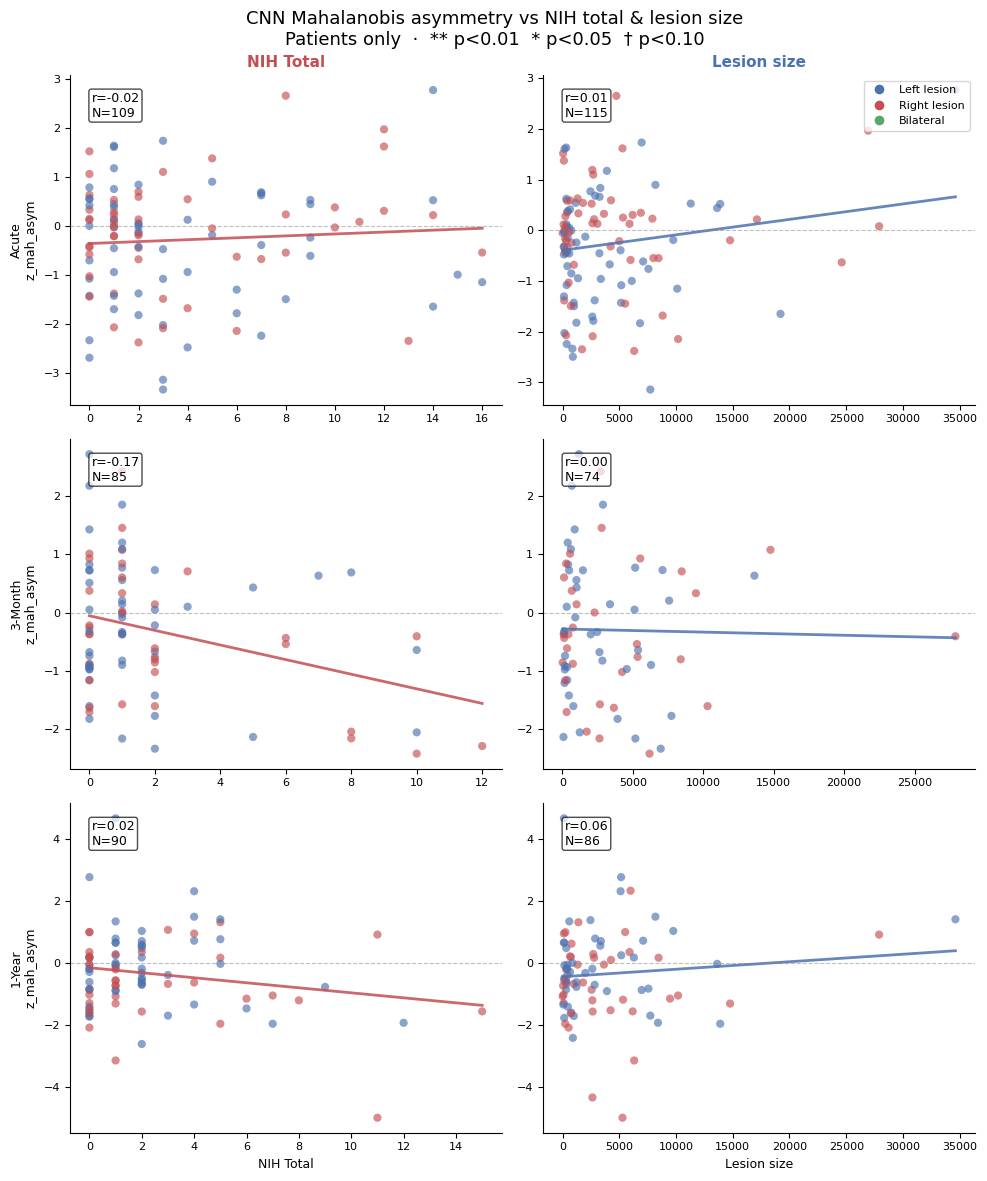

Saved → cnn_mah_asym_vs_outcomes.png


In [15]:
# pat is already defined from the inner merge — use it directly
pat = merged[merged['subj_type'] == 0].copy()
print(f"Patients: {pat['ID'].nunique()} subjects, {len(pat)} sessions")

# ── LESION SIDE DIRECTIONALITY ────────────────────────────────────
print("\n=== Mah asymmetry by lesion side (Acute) ===")
acute_pat = pat[pat['Session'] == 'acute']
for side, label in [(0,'Left lesion'), (1,'Right lesion'), (2,'Bilateral')]:
    sub = acute_pat[acute_pat['lesion_side'] == side]['z_cnn_mah_asym'].dropna()
    if len(sub) == 0: continue
    print(f"  {label}: median={sub.median():+.3f}  mean={sub.mean():+.3f}  N={len(sub)}")

# ── SPEARMAN vs NIH_TOTAL AND LESION_SIZE ─────────────────────────
sessions  = ['acute', 'followup2', 'followup']
ses_label = {'acute':'Acute', 'followup2':'3-Month', 'followup':'1-Year'}
eye_metrics = {
    'z_cnn_mah_asym': 'Mah asym (L−R)',
    'z_abs_mah_L':    '|Mah dev| Left',
    'z_abs_mah_R':    '|Mah dev| Right',
    'z_cnn_cos_L':    'Cos stability Left',
    'z_cnn_cos_R':    'Cos stability Right',
    'z_cnn_wass_LR':  'Wasserstein L↔R',
}
outcomes = {'nih_total': 'NIH Total', 'lesion_size': 'Lesion size'}

rows = []
for ses in sessions:
    sub = pat[pat['Session'] == ses]
    for em, em_lbl in eye_metrics.items():
        for oc, oc_lbl in outcomes.items():
            data = sub[[em, oc]].dropna()
            if len(data) < 5: continue
            r, p = spearmanr(data[em], data[oc])
            rows.append({'Session': ses_label[ses], 'Metric': em_lbl,
                         'Outcome': oc_lbl, 'r': round(r,3), 'p': round(p,4),
                         'N': len(data),
                         'sig': '**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else ''))})

df_corr = pd.DataFrame(rows)
print("\n=== Spearman r ===")
print(df_corr.to_string(index=False))

# ── SCATTER GRID ─────────────────────────────────────────────────
colors = {'NIH Total':'#C44E52', 'Lesion size':'#4C72B0'}
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle('CNN Mahalanobis asymmetry vs NIH total & lesion size\n'
             'Patients only  ·  ** p<0.01  * p<0.05  † p<0.10', fontsize=13)

for row_i, ses in enumerate(sessions):
    for col_i, (oc, oc_lbl) in enumerate(outcomes.items()):
        ax  = axes[row_i, col_i]
        sub = pat[pat['Session'] == ses][['z_cnn_mah_asym', oc, 'lesion_side']].dropna(subset=['z_cnn_mah_asym', oc])

        side_colors = sub['lesion_side'].map({0:'#4C72B0', 1:'#C44E52', 2:'#55A868'}).fillna('grey')
        ax.scatter(sub[oc], sub['z_cnn_mah_asym'],
                   c=side_colors, alpha=0.65, s=35, edgecolors='none')

        if len(sub) >= 5:
            m, b = np.polyfit(sub[oc], sub['z_cnn_mah_asym'], 1)
            xl = np.linspace(sub[oc].min(), sub[oc].max(), 100)
            ax.plot(xl, m*xl+b, color=colors[oc_lbl], lw=2, alpha=0.85)

        r_row = df_corr[(df_corr['Session']==ses_label[ses]) &
                        (df_corr['Outcome']==oc_lbl) &
                        (df_corr['Metric']=='Mah asym (L−R)')]
        if len(r_row):
            ax.text(0.05, 0.95,
                    f"r={r_row['r'].values[0]:.2f}{r_row['sig'].values[0]}\nN={r_row['N'].values[0]}",
                    transform=ax.transAxes, va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

        ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
        if row_i == 0:
            ax.set_title(oc_lbl, fontsize=11, color=colors[oc_lbl], fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{ses_label[ses]}\nz_mah_asym', fontsize=9)
        if row_i == 2:
            ax.set_xlabel(oc_lbl, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.spines[['top','right']].set_visible(False)

# Legend for lesion side colors
from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
              for c, l in [('#4C72B0','Left lesion'),('#C44E52','Right lesion'),('#55A868','Bilateral')]]
axes[0,1].legend(handles=legend_els, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('cnn_mah_asym_vs_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → cnn_mah_asym_vs_outcomes.png")

In [13]:
# Check what's actually in df_res after z-scoring
print("df_res cols:", df_res.columns.tolist())
print("df_res shape:", df_res.shape)

# Check merge worked
print("sc cols with z_:", [c for c in sc.columns if c.startswith('z_')])
print("sc shape:", sc.shape)

# Check ID/Session overlap
print("\ndf_res IDs sample:", df_res['ID'].unique()[:5])
print("stroke_csv IDs sample:", stroke_csv['ID'].unique()[:5])
print("df_res Sessions:", df_res['Session'].unique())
print("stroke_csv Sessions:", stroke_csv['Session'].unique())

df_res cols: ['ID', 'Session', 'cnn_mah_L', 'cnn_mah_R', 'cnn_mah_asym', 'cnn_mah_asym_rel', 'cnn_cos_L', 'cnn_cos_R', 'cnn_cos_asym', 'cnn_wass_LR', 'z_cnn_mah_L', 'z_cnn_mah_R', 'z_cnn_cos_L', 'z_cnn_cos_R', 'z_cnn_mah_asym', 'z_cnn_cos_asym', 'z_cnn_wass_LR', 'z_abs_mah_L', 'z_abs_mah_R']
df_res shape: (418, 19)
sc cols with z_: ['z_cnn_mah_L_x', 'z_cnn_mah_R_x', 'z_cnn_cos_L_x', 'z_cnn_cos_R_x', 'z_cnn_mah_asym_x', 'z_cnn_cos_asym_x', 'z_cnn_wass_LR_x', 'z_abs_mah_L_x', 'z_abs_mah_R_x', 'z_cnn_mah_L_y', 'z_cnn_mah_R_y', 'z_cnn_cos_L_y', 'z_cnn_cos_R_y', 'z_cnn_mah_asym_y', 'z_cnn_cos_asym_y', 'z_cnn_wass_LR_y', 'z_abs_mah_L_y', 'z_abs_mah_R_y']
sc shape: (386, 649)

df_res IDs sample: ['CON001' 'CON002' 'CON003' 'CON004' 'CON005']
stroke_csv IDs sample: ['CON001' 'CON002' 'CON003' 'CON004' 'CON005']
df_res Sessions: ['control' 'control2' 'acute' 'followup2' 'followup']
stroke_csv Sessions: ['control' 'control2' 'acute' 'followup' 'followup2']


In [14]:
# Pull just what you need from stroke_csv
clin = stroke_csv[['ID','Session','subj_type','lesion_side',
                    'nih_total','lesion_size','nih2','nih3','nih11',
                    'mes_coc','bit_coc','attention1vf_f']].copy()

# Merge the other direction — start from df_res
z_cols = [c for c in df_res.columns if c.startswith('z_')]
merged = df_res[['ID','Session'] + z_cols].merge(clin, on=['ID','Session'], how='inner')

print("Merged shape:", merged.shape)
print("z_ cols present:", [c for c in merged.columns if c.startswith('z_')])
pat = merged[merged['subj_type'] == 0].copy()

Merged shape: (384, 21)
z_ cols present: ['z_cnn_mah_L', 'z_cnn_mah_R', 'z_cnn_cos_L', 'z_cnn_cos_R', 'z_cnn_mah_asym', 'z_cnn_cos_asym', 'z_cnn_wass_LR', 'z_abs_mah_L', 'z_abs_mah_R']


In [7]:
os.listdir('/mnt/compneuro/deepmreye_finetuning/processed_data_separate_eyes/right/dataset7_resting_state/')

['9001_right.npz',
 '9007_right.npz',
 '9008_right.npz',
 '9013_right.npz',
 '9023_right.npz',
 '9025_right.npz',
 '9029_right.npz',
 '9033_right.npz',
 '9041_right.npz',
 '9048_right.npz',
 '9050_right.npz',
 '9053_right.npz',
 '9055_right.npz',
 '9057_right.npz',
 '9063_right.npz',
 '9070_right.npz',
 '9071_right.npz',
 '9074_right.npz',
 '9077_right.npz',
 '9081_right.npz',
 '9082_right.npz',
 '9083_right.npz',
 '9084_right.npz',
 '9085_right.npz',
 '9087_right.npz',
 '9088_right.npz',
 '9091_right.npz',
 '9092_right.npz',
 '9100_right.npz',
 '9001_left.npz',
 '9007_left.npz',
 '9008_left.npz',
 '9013_left.npz',
 '9023_left.npz',
 '9025_left.npz',
 '9029_left.npz',
 '9033_left.npz',
 '9041_left.npz',
 '9048_left.npz',
 '9050_left.npz',
 '9053_left.npz',
 '9055_left.npz',
 '9057_left.npz',
 '9063_left.npz',
 '9070_left.npz',
 '9071_left.npz',
 '9074_left.npz',
 '9077_left.npz',
 '9081_left.npz',
 '9082_left.npz',
 '9083_left.npz',
 '9084_left.npz',
 '9085_left.npz',
 '9087_left.npz',

In [26]:
stroke_csv=stroke_csv.drop(columns=["PCA_left","PCA_right"])

In [27]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

In [30]:

import os, re
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr

STROKE_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/'
N_PRE      = 10
N_SPLITS   = 5
BATCH_SIZE = 32

# ─── DATA LOADING ─────────────────────────────────────────────────────────────

def load_voxels_and_features(npz_path, extractor):
    f = np.load(npz_path, allow_pickle=True)
    keys = sorted(k for k in f.keys() if k.startswith('data_'))
    vols = np.array([f[k] for k in keys])          # (n_TRs, D, H, W)
    vox  = vols.reshape(len(vols), -1)              # (n_TRs, n_voxels)
    vols_5d = vols[..., np.newaxis]                 # (n_TRs, D, H, W, 1)
    feats = []
    for i in range(0, len(vols_5d), BATCH_SIZE):
        batch = vols_5d[i:i+BATCH_SIZE]
        feats.append(extractor(batch, training=False).numpy())
    feats = np.concatenate(feats, axis=0)           # (n_TRs, 4608)
    return vox, feats

# ─── METHODS ──────────────────────────────────────────────────────────────────

def pca_rl_r_raw(vox_l, vox_r):
    def pc1(vox):
        scaled = StandardScaler().fit_transform(vox)
        return PCA(n_components=1).fit_transform(scaled)[:, 0]
    r, _ = pearsonr(pc1(vox_l), pc1(vox_r))
    return float(abs(r))

def get_pca_timeseries(vox_l, vox_r):
    """PC1 timeseries for each eye from raw voxels."""
    def pc1(vox):
        scaled = StandardScaler().fit_transform(vox)
        return PCA(n_components=1).fit_transform(scaled)[:, 0]
    return pc1(vox_l), pc1(vox_r)   # (128,), (128,)

def get_cca_timeseries(feats_l, feats_r, n_pre=N_PRE):
    """
    CCA canonical variates fit on ALL data — Option A.
    Used for timeseries storage only (not for the r metric).
    Pipeline: CNN feats → StandardScaler → PCA(10) → CCA(1)
    Returns CCA_left (128,), CCA_right (128,)
    """
    sl  = StandardScaler().fit(feats_l)
    sr  = StandardScaler().fit(feats_r)
    pl  = PCA(n_components=n_pre).fit(sl.transform(feats_l))
    pr  = PCA(n_components=n_pre).fit(sr.transform(feats_r))
    L   = pl.transform(sl.transform(feats_l))   # (128, 10)
    R   = pr.transform(sr.transform(feats_r))
    cca = CCA(n_components=1).fit(L, R)
    Lc, Rc = cca.transform(L, R)                # (128, 1) each
    return Lc[:, 0], Rc[:, 0]                   # (128,), (128,)

def cca_rl_r(feats_l, feats_r, n_pre=N_PRE, n_splits=N_SPLITS):
    """CV-CCA r — unchanged from your original."""
    n, rs = len(feats_l), []
    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        idx = rng.permutation(n)
        tr_idx, te_idx = idx[:n//2], idx[n//2:]
        sl = StandardScaler().fit(feats_l[tr_idx])
        sr = StandardScaler().fit(feats_r[tr_idx])
        pl = PCA(n_components=n_pre).fit(sl.transform(feats_l[tr_idx]))
        pr = PCA(n_components=n_pre).fit(sr.transform(feats_r[tr_idx]))
        Ltr = pl.transform(sl.transform(feats_l[tr_idx]))
        Rtr = pr.transform(sr.transform(feats_r[tr_idx]))
        Lte = pl.transform(sl.transform(feats_l[te_idx]))
        Rte = pr.transform(sr.transform(feats_r[te_idx]))
        cca = CCA(n_components=1).fit(Ltr, Rtr)
        Lc, Rc = cca.transform(Lte, Rte)
        r, _ = pearsonr(Lc[:, 0], Rc[:, 0])
        rs.append(r)
    return float(np.mean(rs)), float(np.std(rs))

# ─── MAIN LOOP ────────────────────────────────────────────────────────────────

left_files = sorted(f for f in os.listdir(STROKE_DIR) if f.endswith('_left.npz'))
results = []

for left_fname in left_files:
    right_fname = left_fname.replace('_left.npz', '_right.npz')
    left_path   = os.path.join(STROKE_DIR, left_fname)
    right_path  = os.path.join(STROKE_DIR, right_fname)

    if not os.path.exists(right_path):
        print(f"  SKIP: {left_fname}")
        continue

    m = re.match(r'(\w+)_sub-\w+_ses-(\w+)_task-rest_run-0_bold_left\.npz', left_fname)
    subj_id = m.group(1) if m else left_fname
    session = m.group(2) if m else '?'

    vox_l, feats_l = load_voxels_and_features(left_path,  feature_extractor_left)
    vox_r, feats_r = load_voxels_and_features(right_path, feature_extractor_right)

    pca_raw        = pca_rl_r_raw(vox_l, vox_r)
    cca_r, cca_std = cca_rl_r(feats_l, feats_r)

    pca_left_ts, pca_right_ts = get_pca_timeseries(vox_l, vox_r)
    cca_left_ts, cca_right_ts = get_cca_timeseries(feats_l, feats_r)

    results.append(dict(
        ID=subj_id, Session=session,
        PCA_raw = round(pca_raw, 3),
        CCA     = round(cca_r,   3),
        CCA_std = round(cca_std, 3),
        # timeseries stored as lists (128 values each)
        PCA_left  = pca_left_ts.tolist(),
        PCA_right = pca_right_ts.tolist(),
        CCA_left  = cca_left_ts.tolist(),
        CCA_right = cca_right_ts.tolist(),
    ))
    print(f"{subj_id:12s} {session:10s} | PCA_raw={pca_raw:.3f}  CCA={cca_r:.3f}±{cca_std:.3f}")

df_results = pd.DataFrame(results)

# ─── MERGE INTO stroke_csv ────────────────────────────────────────────────────
# stroke_csv already has one row per (ID, Session)
# We merge on those two keys so timeseries land in the right rows

merge_cols = ['ID', 'Session', 'PCA_raw', 'CCA', 'CCA_std',
              'PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']

stroke_csv = stroke_csv.merge(
    df_results[merge_cols],
    on=['ID', 'Session'],
    how='left'
)

print(f"\nstroke_csv shape after merge: {stroke_csv.shape}")
print(f"Timeseries columns added: PCA_left, PCA_right, CCA_left, CCA_right")
print(f"NaN rows (no npz match): {stroke_csv['PCA_left'].isna().sum()}")

# Save scalar metrics to CSV (timeseries columns are not CSV-friendly)
#stroke_csv.drop(columns=['PCA_left','PCA_right','CCA_left','CCA_right']
              # ).to_csv('stroke_csv_with_metrics.csv', index=False)
#print("Saved scalar metrics → stroke_csv_with_metrics.csv")
# stroke_csv (with timeseries) lives in memory for downstream analysis

CON001       control    | PCA_raw=0.297  CCA=0.647±0.070
CON002       control2   | PCA_raw=0.963  CCA=0.918±0.013
CON002       control    | PCA_raw=0.985  CCA=0.893±0.040
CON003       control2   | PCA_raw=0.799  CCA=0.772±0.056
CON003       control    | PCA_raw=0.959  CCA=0.797±0.058
CON004       control2   | PCA_raw=0.990  CCA=0.854±0.018
CON005       control2   | PCA_raw=0.951  CCA=0.847±0.019
CON005       control    | PCA_raw=0.947  CCA=0.878±0.036
CON006       control2   | PCA_raw=0.699  CCA=0.400±0.099
CON006       control    | PCA_raw=0.858  CCA=0.703±0.086
CON007       control2   | PCA_raw=0.950  CCA=0.525±0.063
CON007       control    | PCA_raw=0.850  CCA=0.640±0.093
CON008       control    | PCA_raw=0.943  CCA=0.693±0.089
CON009       control2   | PCA_raw=0.954  CCA=0.534±0.043
CON009       control    | PCA_raw=0.981  CCA=0.725±0.076
CON010       control2   | PCA_raw=0.951  CCA=0.444±0.108
CON011       control2   | PCA_raw=0.904  CCA=0.567±0.081
CON011       control    | PCA_r

In [32]:
stroke_csv.columns.values

array(['ID', 'Session', 'Run', 'Eyes', 'corrmats', 'gradient_corrmat',
       'lambda_corrmats', 'mean_corrmats', 'gradient_corrmat_mean',
       'lambda_corrmats_mean', 'corrmats_corrected',
       'gradient_corrmat_corrected', 'mean_corrmats_corrected',
       'gradient_corrmat_corrected_mean',
       'lambda_corrmats_corrected_mean', 'subj_type', 'inclusion_notes',
       'lesion_side', 'acute_beh', 'acute_scan', 'three_m_beh',
       'three_m_scan', 'one_y_beh', 'one_y_scan', 'v1_beh', 'v1_scan',
       'v2_beh', 'v2_scan', 'age', 'ethnicity', 'race', 'gender',
       'education', 'handed', 'smoke', 'neuro_pmh___0', 'neuro_pmh___1',
       'neuro_pmh___2', 'neuro_pmh___3', 'psy_pmh___0', 'psy_pmh___1',
       'psy_pmh___2', 'psy_pmh___3', 'psy_pmh___4', 'cardio_pmh___0',
       'cardio_pmh___1', 'cardio_pmh___2', 'cardio_pmh___3',
       'cardio_pmh___4', 'cardio_pmh___5', 'dm', 'vision_pmh___0',
       'vision_pmh___1', 'vision_pmh___2', 'vision_pmh___3',
       'date_stroke', 'tp

Non-NaN counts per session:
           var_PCA_left  var_PCA_right  var_CCA_left  var_CCA_right  nih_total
Session                                                                       
acute               137            137           137            137        110
followup            103            103           103            103         90
followup2            86             86            86             86         86

=== Spearman r (variance ~ nih_total) ===
Session   Feature      r      p   N sig
  Acute  PCA_left  0.220 0.0218 109   *
  Acute PCA_right  0.216 0.0241 109   *
  Acute  CCA_left  0.022 0.8210 109    
  Acute CCA_right -0.063 0.5151 109    
3-Month  PCA_left  0.117 0.2864  85    
3-Month PCA_right  0.104 0.3422  85    
3-Month  CCA_left -0.011 0.9224  85    
3-Month CCA_right -0.036 0.7440  85    
 1-Year  PCA_left  0.086 0.4227  90    
 1-Year PCA_right  0.096 0.3697  90    
 1-Year  CCA_left  0.097 0.3629  90    
 1-Year CCA_right -0.049 0.6435  90    


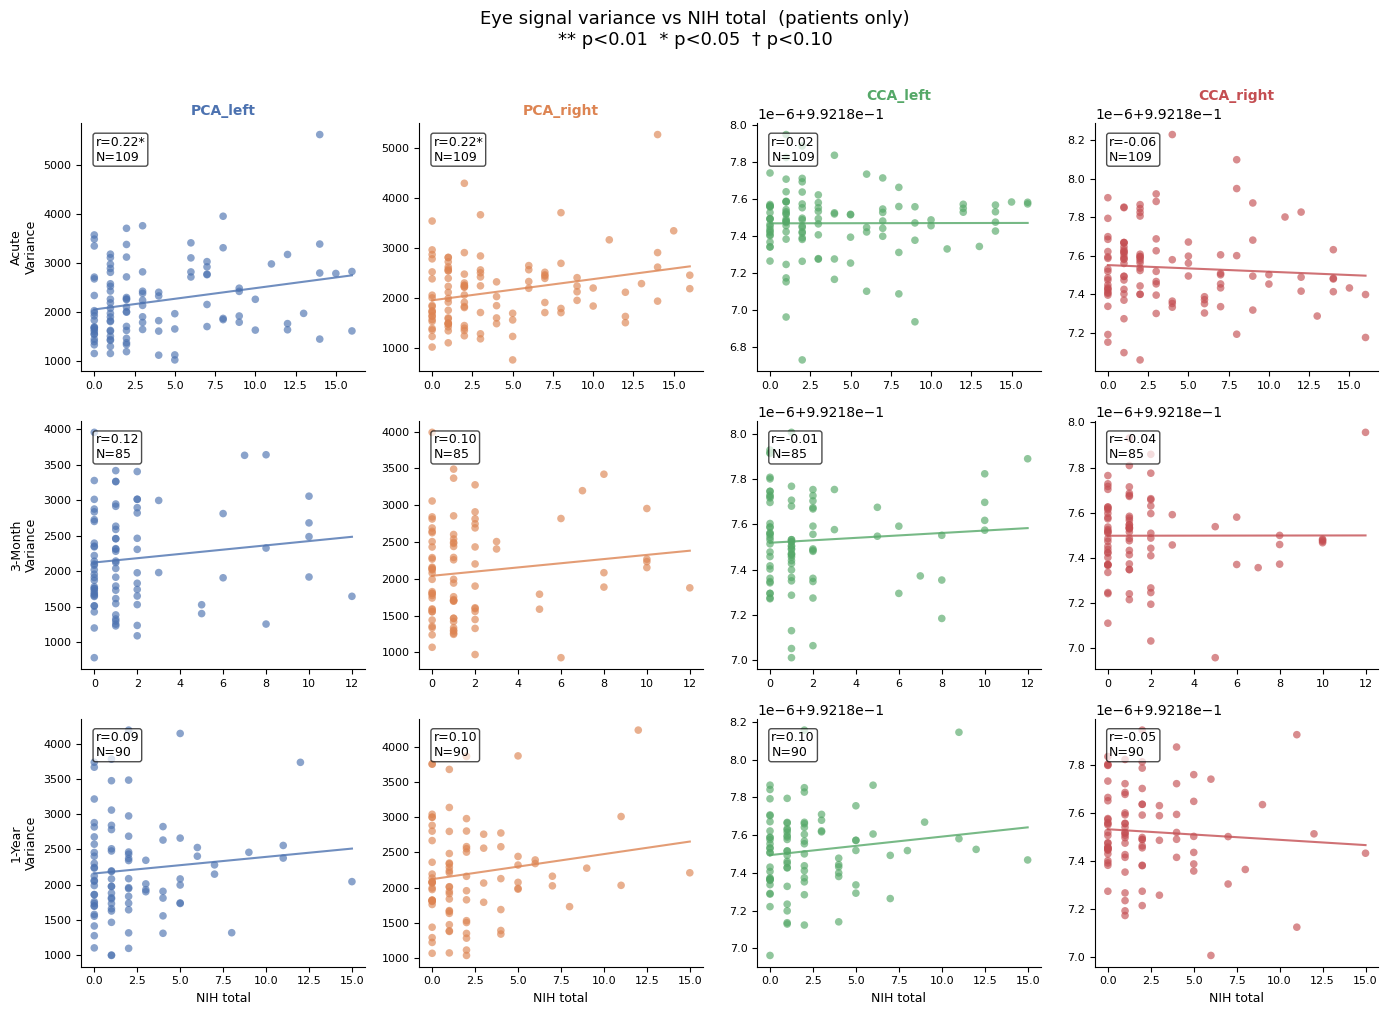

Saved → variance_vs_nih.png


In [38]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── 1. COMPUTE VARIANCES ──────────────────────────────────────────
ts_cols = ['PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']
df = stroke_csv[stroke_csv['subj_type'] == 0].copy()   # patients only

for col in ts_cols:
    df[f'var_{col}'] = df[col].apply(
        lambda x: float(np.var(x)) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else np.nan
    )

var_cols  = [f'var_{c}' for c in ts_cols]
print("Non-NaN counts per session:")
print(df.groupby('Session')[var_cols + ['nih_total']].count())

# ── 2. SPEARMAN CORRELATIONS ──────────────────────────────────────
sessions  = ['acute', 'followup2', 'followup']
ses_label = {'acute': 'Acute', 'followup2': '3-Month', 'followup': '1-Year'}

rows = []
for ses in sessions:
    sub = df[df['Session'] == ses]
    for vc in var_cols:
        data = sub[[vc, 'nih_total']].dropna()
        if len(data) < 5: continue
        r, p = spearmanr(data[vc], data['nih_total'])
        rows.append({
            'Session': ses_label[ses], 'Feature': vc.replace('var_',''),
            'r': round(r,3), 'p': round(p,4), 'N': len(data),
            'sig': '**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else ''))
        })

df_corr = pd.DataFrame(rows)
print("\n=== Spearman r (variance ~ nih_total) ===")
print(df_corr.to_string(index=False))

# ── 3. SCATTER GRID ───────────────────────────────────────────────
colors = {'PCA_left':'#4C72B0','PCA_right':'#DD8452',
          'CCA_left':'#55A868','CCA_right':'#C44E52'}

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Eye signal variance vs NIH total  (patients only)\n'
             '** p<0.01  * p<0.05  † p<0.10', fontsize=13, y=1.01)

for row_i, ses in enumerate(sessions):
    sub = df[df['Session'] == ses]
    for col_i, vc in enumerate(var_cols):
        ax   = axes[row_i, col_i]
        feat = vc.replace('var_', '')
        data = sub[[vc, 'nih_total']].dropna()

        ax.scatter(data['nih_total'], data[vc],
                   color=colors[feat], alpha=0.65, s=30, edgecolors='none')

        if len(data) >= 5:
            m, b = np.polyfit(data['nih_total'], data[vc], 1)
            xline = np.linspace(data['nih_total'].min(), data['nih_total'].max(), 100)
            ax.plot(xline, m*xline+b, color=colors[feat], lw=1.5, alpha=0.8)

        r_row = df_corr[(df_corr['Session']==ses_label[ses]) & (df_corr['Feature']==feat)]
        if len(r_row):
            r_val, sig, n_val = r_row['r'].values[0], r_row['sig'].values[0], r_row['N'].values[0]
            ax.text(0.05, 0.95, f'r={r_val:.2f}{sig}\nN={n_val}',
                    transform=ax.transAxes, va='top', ha='left', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

        if row_i == 0:
            ax.set_title(feat, fontsize=10, color=colors[feat], fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{ses_label[ses]}\nVariance', fontsize=9)
        ax.set_xlabel('NIH total' if row_i == 2 else '', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('variance_vs_nih.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → variance_vs_nih.png")

Session                       Eye                  Outcome      r      p   N sig
3-Month Bilateral coherence (raw)      NIHSS Visual Fields  0.319 0.0028  86  **
 1-Year       Var asymmetry (PCA)        Posner RT VF bias -0.310 0.0031  89  **
3-Month         PC1 variance left      NIHSS Visual Fields  0.300 0.0051  86  **
  Acute Bilateral coherence (raw)               NIHSS Gaze -0.261 0.0059 110  **
  Acute       Var asymmetry (PCA)       Posner Acc VF bias  0.245 0.0087 114  **
  Acute         PC1 variance left NIHSS Extinction/Neglect  0.245 0.0100 110   *
  Acute         PC1 variance left        Posner RT VF bias  0.231 0.0157 109   *
 1-Year Bilateral coherence (raw)          BIT Left Misses -0.237 0.0171 101   *
3-Month        PC1 variance right      NIHSS Visual Fields  0.251 0.0196  86   *
 1-Year         PC1 variance left          BIT Left Misses -0.232 0.0198 101   *
  Acute         PC1 variance left              NIHSS Total  0.220 0.0218 109   *
  Acute       Var asymmetry 

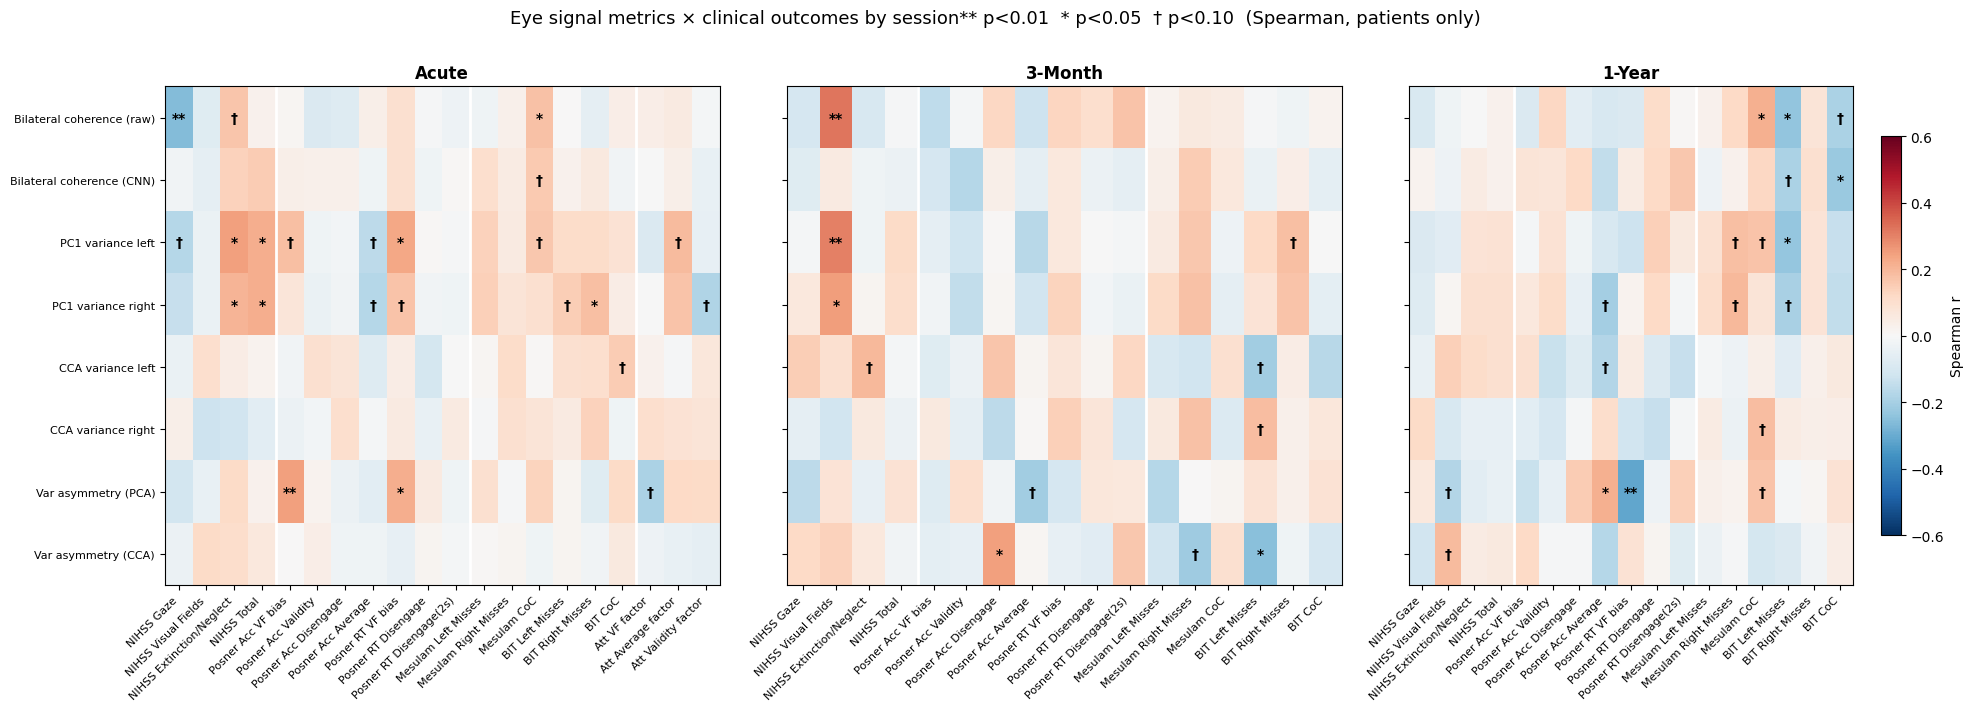

Saved → eye_metrics_outcomes_heatmap.png
Saved → eye_metrics_outcomes_correlations.csv


In [41]:

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── 1. COMPUTE EYE METRICS FROM TIMESERIES ───────────────────────
ts_cols = ['PCA_left', 'PCA_right', 'CCA_left', 'CCA_right']
df = stroke_csv[stroke_csv['subj_type'] == 0].copy()

for col in ts_cols:
    df[f'var_{col}'] = df[col].apply(
        lambda x: float(np.var(x)) if isinstance(x, (list, np.ndarray)) and len(x) > 0 else np.nan
    )

# Asymmetry: log(var_L / var_R) — positive = L more variable, negative = R
df['var_asym_PCA'] = np.log(df['var_PCA_left']  / (df['var_PCA_right']  + 1e-9))
df['var_asym_CCA'] = np.log(df['var_CCA_left']  / (df['var_CCA_right']  + 1e-9))

# All eye metrics to test
eye_metrics = {
    'PCA_raw':       'Bilateral coherence (raw)',
    'CCA':           'Bilateral coherence (CNN)',
    'var_PCA_left':  'PC1 variance left',
    'var_PCA_right': 'PC1 variance right',
    'var_CCA_left':  'CCA variance left',
    'var_CCA_right': 'CCA variance right',
    'var_asym_PCA':  'Var asymmetry (PCA)',
    'var_asym_CCA':  'Var asymmetry (CCA)',
}

# ── 2. OUTCOME VARIABLES ─────────────────────────────────────────
# NIHSS visual/attention subscores
outcomes_nihss = {
    'nih2':  'NIHSS Gaze',
    'nih3':  'NIHSS Visual Fields',
    'nih11': 'NIHSS Extinction/Neglect',
    'nih_total': 'NIHSS Total',
}

# Posner (spatial attention, validity, disengagement)
outcomes_posner = {
    'pos_acc_vf':         'Posner Acc VF bias',
    'pos_acc_validity':   'Posner Acc Validity',
    'pos_acc_disengage':  'Posner Acc Disengage',
    'pos_acc_avg':        'Posner Acc Average',
    'pos_rt_vf':          'Posner RT VF bias',
    'pos_rt_disengage':   'Posner RT Disengage',
    'pos_sub_disengage':  'Posner RT Disengage(2s)',
}

# Cancellation (neglect)
outcomes_cancel = {
    'mes_l_miss':    'Mesulam Left Misses',
    'mes_r_miss':    'Mesulam Right Misses',
    'mes_coc':       'Mesulam CoC',
    'bit_ltot_miss': 'BIT Left Misses',
    'bit_rtot_miss': 'BIT Right Misses',
    'bit_coc':       'BIT CoC',
}

# Composite factor scores
outcomes_factors = {
    'attention1vf_f':          'Att VF factor',
    'attention2avg_f':         'Att Average factor',
    'attention3val_f':         'Att Validity factor',
    'revised_attvf_factor':    'Att VF (revised)',
    'revised_attave_factor':   'Att Ave (revised)',
    'revised_attvaldis_factor':'Att ValDis (revised)',
}

all_outcomes = {**outcomes_nihss, **outcomes_posner, **outcomes_cancel, **outcomes_factors}

# ── 3. SPEARMAN CORRELATION MATRIX PER SESSION ───────────────────
sessions  = ['acute', 'followup2', 'followup']
ses_label = {'acute': 'Acute', 'followup2': '3-Month', 'followup': '1-Year'}

rows = []
for ses in sessions:
    sub = df[df['Session'] == ses]
    for em, em_label in eye_metrics.items():
        for out, out_label in all_outcomes.items():
            if out not in sub.columns:
                continue
            data = sub[[em, out]].dropna()
            if len(data) < 8:
                continue
            r, p = spearmanr(data[em], data[out])
            rows.append({
                'Session':   ses_label[ses],
                'Eye':       em_label,
                'Outcome':   out_label,
                'r':         round(r, 3),
                'p':         round(p, 4),
                'N':         len(data),
                'sig':       '**' if p < 0.01 else ('*' if p < 0.05 else ('†' if p < 0.10 else ''))
            })

df_corr = pd.DataFrame(rows)
print(df_corr[df_corr['sig'] != ''].sort_values('p').to_string(index=False))
print(f"\nTotal tested: {len(df_corr)}  |  Significant (p<0.05): {(df_corr['p']<0.05).sum()}")

# ── 4. HEATMAP: r values, rows=eye metrics, cols=outcomes, one per session ──
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

dividers = [4, 4+7, 4+7+6]   # boundaries between outcome groups
group_labels = ['NIHSS', 'Posner', 'Cancellation', 'Factors']

for ax, ses in zip(axes, sessions):
    sub_corr = df_corr[df_corr['Session'] == ses_label[ses]]
    pivot = sub_corr.pivot_table(index='Eye', columns='Outcome', values='r', aggfunc='first')
    pivot_p = sub_corr.pivot_table(index='Eye', columns='Outcome', values='p', aggfunc='first')
    pivot_sig = sub_corr.pivot_table(index='Eye', columns='Outcome', values='sig', aggfunc='first')

    # Reorder
    eye_order = list(eye_metrics.values())
    out_order  = [v for v in all_outcomes.values() if v in pivot.columns]
    pivot = pivot.reindex(index=eye_order, columns=out_order)
    pivot_sig = pivot_sig.reindex(index=eye_order, columns=out_order)

    im = ax.imshow(pivot.values.astype(float), aspect='auto',
                   cmap='RdBu_r', vmin=-0.6, vmax=0.6)

    # significance markers
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            sig = pivot_sig.values[i, j] if pivot_sig.values[i, j] is not None else ''
            if not np.isnan(float(val)) if isinstance(val, float) else False:
                ax.text(j, i, sig if sig else '', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='k')

    ax.set_xticks(range(len(out_order)))
    ax.set_xticklabels(out_order, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(eye_order)))
    ax.set_yticklabels(eye_order, fontsize=8)
    ax.set_title(ses_label[ses], fontsize=12, fontweight='bold')

    # group dividers
    cumulative = [0, len(outcomes_nihss), len(outcomes_nihss)+len(outcomes_posner),
                  len(outcomes_nihss)+len(outcomes_posner)+len(outcomes_cancel)]
    for div in cumulative[1:]:
        if div < len(out_order):
            ax.axvline(div - 0.5, color='white', lw=2)

plt.colorbar(im, ax=axes[-1], label="Spearman r", shrink=0.8)
fig.suptitle('Eye signal metrics × clinical outcomes by session'
             '** p<0.01  * p<0.05  † p<0.10  (Spearman, patients only)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eye_metrics_outcomes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → eye_metrics_outcomes_heatmap.png")

df_corr.to_csv('eye_metrics_outcomes_correlations.csv', index=False)
print("Saved → eye_metrics_outcomes_correlations.csv")

In [20]:

import os, glob
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr, rankdata
import warnings
warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
NPZ_DIR  = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti"
N_PCA    = 10    # PCA components before CCA (dimensionality reduction)
N_SPLITS = 20    # CCA cross-val folds
# stroke_csv must already be loaded as a DataFrame
# ════════════════════════════════════════════════════════════════

# ── 0. FILE INDEX ─────────────────────────────────────────────────
all_npzs = glob.glob(os.path.join(NPZ_DIR, "*.npz"))
print(f"NPZ files found: {len(all_npzs)}")

file_index = {}
for f in all_npzs:
    bn   = os.path.basename(f)
    subj = bn.split("_sub-")[0]
    ses_tok = [p for p in bn.split("_") if p.startswith("ses-")]
    if not ses_tok: continue
    session = ses_tok[0].replace("ses-", "")
    stem = bn.replace(".npz", "")
    if   stem.endswith("_left"):  eye = "left"
    elif stem.endswith("_right"): eye = "right"
    else:                          eye = "both"
    file_index[(subj, session, eye)] = f
print(f"Indexed: {len(file_index)} (subj, session, eye) entries")

# ── 1. DATA HELPERS ───────────────────────────────────────────────
def load_patch_matrix(path, n_tp=128):
    d = np.load(path, allow_pickle=True)
    patches = []
    for i in range(n_tp):
        key = f"data_{i}"
        if key not in d: break
        patches.append(d[key].astype(np.float32).flatten())
    return np.vstack(patches)          # (T, V)

def load_labels(path, n_tp=128):
    d = np.load(path, allow_pickle=True)
    labels = []
    for i in range(n_tp):
        key = f"label_{i}"
        if key not in d: break
        labels.append(np.array(d[key], dtype=np.float32).flatten())
    return np.vstack(labels) if labels else None

# ── 2. PCA + CCA ─────────────────────────────────────────────────
def get_pca_scores(X, n_components=N_PCA):
    """Z-score columns, PCA → (scores (T,K), pc1 (T,), var_explained (K,))"""
    Xs     = StandardScaler().fit_transform(X)
    pca    = PCA(n_components=n_components)
    scores = pca.fit_transform(Xs)
    return scores, scores[:, 0], pca.explained_variance_ratio_

def cca_cv_multivariate(scores_L, scores_R, n_splits=N_SPLITS):
    """
    CV-CCA on (T×K) PCA score matrices.
    This is the correct CCA: finds the SHARED spatial component
    across left and right eye patches — not just PC1 correlation.
    Reproduces the CCA=0.7±0.04 metric from the earlier analysis.
    """
    T, sz, rs = scores_L.shape[0], scores_L.shape[0] // n_splits, []
    for i in range(n_splits):
        val = np.arange(i * sz, (i + 1) * sz)
        tr  = np.concatenate([np.arange(0, i * sz), np.arange((i+1)*sz, T)])
        try:
            cca = CCA(n_components=1, max_iter=1000)
            cca.fit(scores_L[tr], scores_R[tr])
            lp, rp = cca.transform(scores_L[val], scores_R[val])
            rs.append(pearsonr(lp[:, 0], rp[:, 0])[0])
        except Exception:
            pass
    return float(np.nanmean(rs)), float(np.nanstd(rs))

# ── 3. FEATURE DICT ───────────────────────────────────────────────
def eye_features(pc_L, pc_R, scores_L, scores_R, evar_L, evar_R):
    f = {}
    # ─ PC1-based features ─
    f["pca_mean_L"]    = float(np.mean(pc_L))
    f["pca_mean_R"]    = float(np.mean(pc_R))
    f["pca_var_L"]     = float(np.var(pc_L))
    f["pca_var_R"]     = float(np.var(pc_R))
    f["pca_RL_r"]      = float(pearsonr(pc_L, pc_R)[0])
    pooled = float(np.std(np.concatenate([pc_L, pc_R]))) + 1e-9
    f["pca_RL_asym"]   = float(abs(np.mean(pc_L) - np.mean(pc_R)) / pooled)
    f["pca_var_asym"]  = float(np.log((np.var(pc_L)+1e-9)/(np.var(pc_R)+1e-9)))
    xcorr = np.correlate(pc_L - pc_L.mean(), pc_R - pc_R.mean(), mode="full")
    xcorr /= (len(pc_L) * (pc_L.std()+1e-9) * (pc_R.std()+1e-9))
    lags = np.arange(-len(pc_L)+1, len(pc_L))
    f["pca_xcorr_peak"] = float(xcorr.max())
    f["pca_xcorr_lag"]  = int(lags[xcorr.argmax()])
    # ─ Variance explained ─
    f["pca_var_explained_L"] = float(evar_L[0])
    f["pca_var_explained_R"] = float(evar_R[0])
    f["pca_cumvar_L"]        = float(evar_L.sum())
    f["pca_cumvar_R"]        = float(evar_R.sum())
    # ─ Per-PC correlation and asymmetry (PC1–PC3) ─
    for k in range(min(3, scores_L.shape[1])):
        f[f"pca_RL_r_pc{k+1}"] = float(pearsonr(scores_L[:,k], scores_R[:,k])[0])
        f[f"pca_var_asym_pc{k+1}"] = float(
            np.log((np.var(scores_L[:,k])+1e-9)/(np.var(scores_R[:,k])+1e-9)))
    return f

# ── 4. CLINICAL DATA ──────────────────────────────────────────────
df_clin = stroke_csv.copy()
vis_cols = ["visual_er___1","visual_er___2","visual_er___3",
            "visual_acute_ad___1","visual_acute_ad___2","visual_acute_ad___3"]
for c in vis_cols:
    if c not in df_clin.columns: df_clin[c] = 0
df_clin["any_visual"] = df_clin[vis_cols].fillna(0).max(axis=1).astype(bool)
df_clin["field_cut"]  = df_clin[["visual_er___1","visual_acute_ad___1"]].fillna(0).max(axis=1).astype(bool)
df_clin["diplopia"]   = df_clin[["visual_er___2","visual_acute_ad___2"]].fillna(0).max(axis=1).astype(bool)
df_clin["other_vis"]  = df_clin[["visual_er___3","visual_acute_ad___3"]].fillna(0).max(axis=1).astype(bool)
for col in ["nih2","nih3","nih11"]:
    if col not in df_clin.columns: df_clin[col] = np.nan
df_clin["nih_visual_sum"] = df_clin[["nih2","nih3","nih11"]].fillna(0).sum(axis=1)

# ── 5. MAIN LOOP ──────────────────────────────────────────────────
records, skipped = [], []

for _, row in df_clin.iterrows():
    subj_id = str(row["ID"])
    session  = str(row.get("Session", "acute"))
    key_L   = (subj_id, session, "left")
    key_R   = (subj_id, session, "right")

    if key_L not in file_index or key_R not in file_index:
        skipped.append(f"MISSING  {subj_id:12s}  {session}")
        continue

    try:
        X_L = load_patch_matrix(file_index[key_L])
        X_R = load_patch_matrix(file_index[key_R])

        scores_L, pc_L, evar_L = get_pca_scores(X_L, N_PCA)
        scores_R, pc_R, evar_R = get_pca_scores(X_R, N_PCA)

        cca_r_mean, cca_r_std = cca_cv_multivariate(scores_L, scores_R)

        feats = eye_features(pc_L, pc_R, scores_L, scores_R, evar_L, evar_R)
        feats["cca_RL_r_mean"] = cca_r_mean   # TRUE shared spatial component r
        feats["cca_RL_r_std"]  = cca_r_std

        # Gaze label features
        try:
            lbl_L = load_labels(file_index[key_L])
            lbl_R = load_labels(file_index[key_R])
            if lbl_L is not None and lbl_L.shape[1] >= 2:
                feats["gaze_x_mean_L"]  = float(np.mean(lbl_L[:,0]))
                feats["gaze_x_mean_R"]  = float(np.mean(lbl_R[:,0]))
                feats["gaze_y_mean_L"]  = float(np.mean(lbl_L[:,1]))
                feats["gaze_y_mean_R"]  = float(np.mean(lbl_R[:,1]))
                feats["gaze_x_asym"]    = float(np.mean(lbl_L[:,0]) - np.mean(lbl_R[:,0]))
                feats["gaze_y_asym"]    = float(np.mean(lbl_L[:,1]) - np.mean(lbl_R[:,1]))
                feats["gaze_x_var_L"]   = float(np.var(lbl_L[:,0]))
                feats["gaze_x_var_R"]   = float(np.var(lbl_R[:,0]))
                feats["gaze_y_var_L"]   = float(np.var(lbl_L[:,1]))
                feats["gaze_y_var_R"]   = float(np.var(lbl_R[:,1]))
                feats["gaze_x_RL_r"]    = float(pearsonr(lbl_L[:,0], lbl_R[:,0])[0])
                feats["gaze_y_RL_r"]    = float(pearsonr(lbl_L[:,1], lbl_R[:,1])[0])
        except Exception:
            pass

        feats.update({
            "ID": subj_id, "Session": session,
            "subj_type":         row.get("subj_type"),
            "nih_total":         row.get("nih_total"),
            "nih2_gaze":         row.get("nih2"),
            "nih3_vf":           row.get("nih3"),
            "nih11_neglect":     row.get("nih11"),
            "nih_visual_sum":    row.get("nih_visual_sum"),
            "lesion_size":       row.get("lesion_size"),
            "lesion_volume_mm3": row.get("lesion_volume_mm3"),
            "lesion_side":       row.get("lesion_side"),
            "lesion_site":       row.get("lesion_site"),
            "any_visual":        row.get("any_visual"),
            "field_cut":         row.get("field_cut"),
            "diplopia":          row.get("diplopia"),
            "other_vis":         row.get("other_vis"),
        })
        records.append(feats)
        if len(records) % 25 == 0:
            print(f"  ✓ {len(records):3d} sessions processed...")

    except Exception as e:
        skipped.append(f"ERROR    {subj_id:12s}  {session}: {e}")

print(f"\n✓ Extracted : {len(records)} sessions")
print(f"  Skipped   : {len(skipped)}")
for s in skipped[:15]: print(f"    {s}")

df_feat = pd.DataFrame(records)
df_feat.to_csv("eye_features_all_sessions.csv", index=False)
print(f"\nSaved → eye_features_all_sessions.csv  {df_feat.shape}")

# ── 6. CORRELATIONS ───────────────────────────────────────────────
eye_cols     = [c for c in df_feat.columns if c.startswith(("pca_","cca_","gaze_"))]
outcome_vars = ["nih_total","nih2_gaze","nih3_vf","nih11_neglect",
                "nih_visual_sum","lesion_size","lesion_volume_mm3"]

corr_rows = []
for feat in eye_cols:
    for outcome in outcome_vars:
        sub = df_feat[["Session", feat, outcome]].dropna()
        for ses in ["acute","followup2","followup","all"]:
            data = sub if ses == "all" else sub[sub["Session"] == ses]
            if len(data) < 5: continue
            try:
                r_sp, p_sp = spearmanr(data[feat], data[outcome])
                r_pe, p_pe = pearsonr(data[feat], data[outcome])
                corr_rows.append({
                    "Feature": feat, "Outcome": outcome, "Session": ses,
                    "Spearman_r": round(r_sp,3), "Spearman_p": round(p_sp,4),
                    "Pearson_r":  round(r_pe,3), "Pearson_p":  round(p_pe,4),
                    "N": len(data)
                })
            except Exception:
                pass

if not corr_rows:
    print("\n⚠  No correlations. Check NaN counts:")
    for v in outcome_vars:
        if v in df_feat: print(f"  {v}: {df_feat[v].isna().sum()} NaN / {len(df_feat)}")
else:
    df_corr = pd.DataFrame(corr_rows).sort_values("Spearman_p").reset_index(drop=True)
    n = len(df_corr)
    ranks = rankdata(df_corr["Spearman_p"].values)
    df_corr["p_FDR"]   = np.minimum(1.0, df_corr["Spearman_p"].values * n / ranks)
    df_corr["sig_FDR"] = df_corr["p_FDR"] < 0.05
    df_corr.to_csv("eye_stroke_correlations.csv", index=False)

    sig = df_corr[df_corr["sig_FDR"]]
    print(f"\n{'='*70}")
    print(f"Significant (FDR q<0.05): {len(sig)}")
    print(f"{'='*70}")
    if len(sig):
        print(sig[["Feature","Outcome","Session","Spearman_r","Spearman_p","p_FDR","N"]].to_string(index=False))
    else:
        print("None survive FDR. Top 20 uncorrected:")
        print(df_corr[["Feature","Outcome","Session","Spearman_r","Spearman_p","N"]].head(20).to_string(index=False))
    print("\nSaved → eye_stroke_correlations.csv")

NPZ files found: 1254
Indexed: 1254 (subj, session, eye) entries
  ✓  25 sessions processed...
  ✓  50 sessions processed...
  ✓  75 sessions processed...
  ✓ 100 sessions processed...
  ✓ 125 sessions processed...
  ✓ 150 sessions processed...
  ✓ 175 sessions processed...
  ✓ 200 sessions processed...
  ✓ 225 sessions processed...
  ✓ 250 sessions processed...
  ✓ 275 sessions processed...
  ✓ 300 sessions processed...
  ✓ 325 sessions processed...
  ✓ 350 sessions processed...
  ✓ 375 sessions processed...

✓ Extracted : 384 sessions
  Skipped   : 2
    MISSING  PAT105        followup2
    MISSING  PAT133        acute

Saved → eye_features_all_sessions.csv  (384, 49)

Significant (FDR q<0.05): 0
None survive FDR. Top 20 uncorrected:
            Feature           Outcome   Session  Spearman_r  Spearman_p   N
pca_var_explained_R lesion_volume_mm3       all       0.243      0.0000 278
pca_var_explained_R       lesion_size       all       0.243      0.0000 275
          pca_var_R lesion

In [19]:
pwd

'/mnt/compneuro/deepmreye_finetuning/Cemal'

In [17]:
# Paste this quick diagnostic BEFORE the main pipeline
import os, glob, numpy as np

NPZ_DIR = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti'
npzs = glob.glob(os.path.join(NPZ_DIR, '**/*.npz'), recursive=True)
print(f"Found: {len(npzs)} npz files")
print("First 5:", npzs[:5])
if npzs:
    d = np.load(npzs[0], allow_pickle=True)
    print("Keys:", list(d.keys()))

Found: 1254 npz files
First 5: ['/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_left.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_right.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON002_sub-CON002_ses-control2_task-rest_run-0_bold.npz', '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON002_sub-CON002_ses-control2_task-rest_run-0_bold_left.npz']
Keys: ['data_0', 'label_0', 'identifier_0', 'data_1', 'label_1', 'identifier_1', 'data_2', 'label_2', 'identifier_2', 'data_3', 'label_3', 'identifier_3', 'data_4', 'label_4', 'identifier_4', 'data_5', 'label_5', 'identifier_5', 'data_6', 'label_6', 'identifier_6', 'data_7', 'label_7', 'identifier_7', 'data_8', 'label_8', 'identifier_8', 'data_9', 'label_9', 'identifier_9', 'data_10', 'label_10', 'identifier_10'